# Customer Segmentation Analysis

This notebook segments 350 e-commerce customers using K-Means clustering, comparing a naive baseline against three alternative feature configurations, and profiles the resulting segments.

**Note on this revision.** This notebook has been corrected from an earlier draft:
- Two dead cells that referenced undefined variables (leftover from an earlier, discarded preprocessing approach) have been removed.
- The behaviour-focused model's cluster count is now chosen the same way as the full-feature model (highest silhouette score), instead of being copied over without checking.
- One segment label ("At-Risk *Active*-Value Customers") that contradicted its own underlying statistics has been corrected.
- A new section (5a) checks, and discloses, how much of the final segmentation is actually just a recovery of the `City` column.

Read the **Limitations** section at the end before drawing conclusions from this notebook.

## 1. Data Loading & Cleaning

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# Load the dataset

data = pd.read_csv("data/E-commerce_Customer_Behavior.csv")

print(f"Dataset shape: {data.shape}")

Dataset shape: (350, 11)


In [3]:
# View the first few rows

data.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [4]:
# Inspect dataset structure

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


In [5]:
# Check for missing values

missing_values = data.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


In [6]:
# Generate descriptive statistics

data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,350.0,NaN,NaN,NaN,275.5,101.180532,101.0,188.25,275.5,362.75,450.0
Gender,350,2,Female,175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,350.0,NaN,NaN,NaN,33.597143,4.870882,26.0,30.0,32.5,37.0,43.0
City,350,6,New York,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership Type,350,3,Gold,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Spend,350.0,NaN,NaN,NaN,845.381714,362.058695,410.8,502.0,775.2,1160.6,1520.1
Items Purchased,350.0,NaN,NaN,NaN,12.6,4.155984,7.0,9.0,12.0,15.0,21.0
Average Rating,350.0,NaN,NaN,NaN,4.019143,0.580539,3.0,3.5,4.1,4.5,4.9
Discount Applied,350,2,True,175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days Since Last Purchase,350.0,NaN,NaN,NaN,26.588571,13.440813,9.0,15.0,23.0,38.0,63.0


In [7]:
# Check for duplicate records

duplicate_count = data.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [8]:
# Remove the customer identifier

data = data.drop(columns=["Customer ID"])

print(f"Dataset shape after removing Customer ID: {data.shape}")

Dataset shape after removing Customer ID: (350, 10)


In [9]:
# View the dataset after removing the identifier

data.head()

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [10]:
# Identify categorical features

categorical_features = [
    "Gender",
    "City",
    "Membership Type",
    "Discount Applied",
    "Satisfaction Level"
]

categorical_features

['Gender', 'City', 'Membership Type', 'Discount Applied', 'Satisfaction Level']

In [11]:
# Identify numerical features

numerical_features = [
    "Age",
    "Total Spend",
    "Items Purchased",
    "Average Rating",
    "Days Since Last Purchase"
]

numerical_features

['Age',
 'Total Spend',
 'Items Purchased',
 'Average Rating',
 'Days Since Last Purchase']

In [12]:
# Handle missing values in Satisfaction Level

data["Satisfaction Level"] = data["Satisfaction Level"].fillna(
    data["Satisfaction Level"].mode()[0]
)

print("Missing values after imputation:")
print(data.isnull().sum())

Missing values after imputation:
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64


In [13]:
# Verify categorical values after preprocessing

for column in categorical_features:
    print(f"\n{column}:")
    print(data[column].value_counts())


Gender:
Gender
Female    175
Male      175
Name: count, dtype: int64

City:
City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64

Membership Type:
Membership Type
Gold      117
Silver    117
Bronze    116
Name: count, dtype: int64

Discount Applied:
Discount Applied
True     175
False    175
Name: count, dtype: int64

Satisfaction Level:
Satisfaction Level
Satisfied      127
Unsatisfied    116
Neutral        107
Name: count, dtype: int64


## 2. Exploratory Data Analysis


Age
--------------------------------------------------
count    350.000000
mean      33.597143
std        4.870882
min       26.000000
25%       30.000000
50%       32.500000
75%       37.000000
max       43.000000
Name: Age, dtype: float64


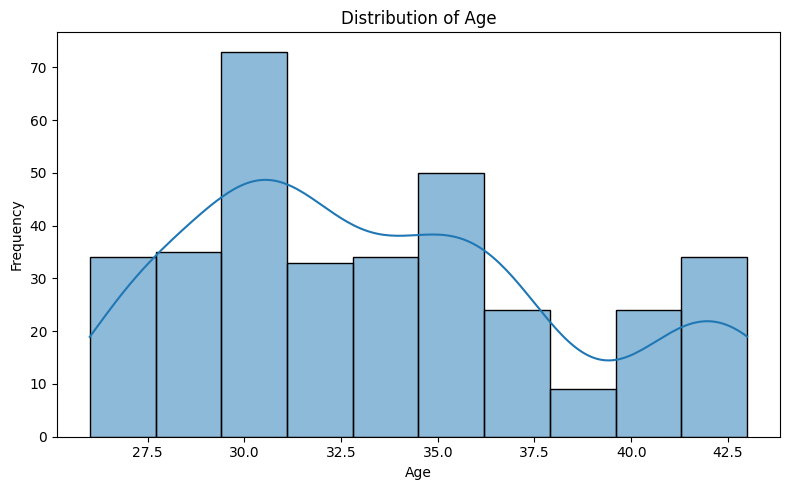


Total Spend
--------------------------------------------------
count     350.000000
mean      845.381714
std       362.058695
min       410.800000
25%       502.000000
50%       775.200000
75%      1160.600000
max      1520.100000
Name: Total Spend, dtype: float64


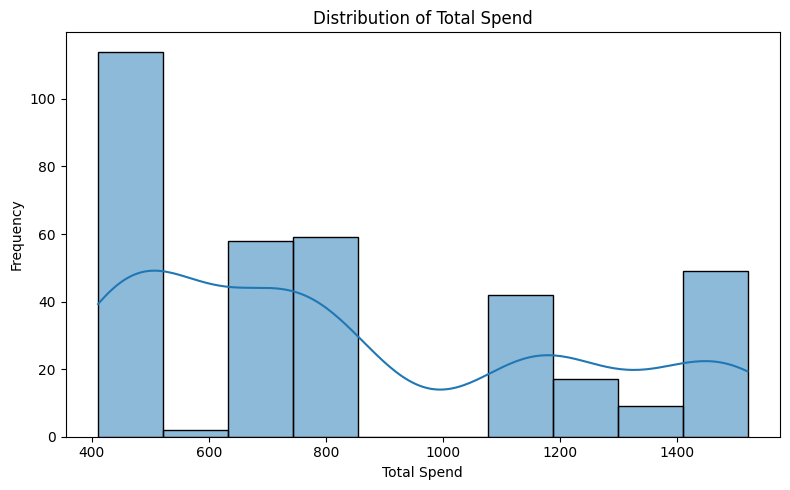


Items Purchased
--------------------------------------------------
count    350.000000
mean      12.600000
std        4.155984
min        7.000000
25%        9.000000
50%       12.000000
75%       15.000000
max       21.000000
Name: Items Purchased, dtype: float64


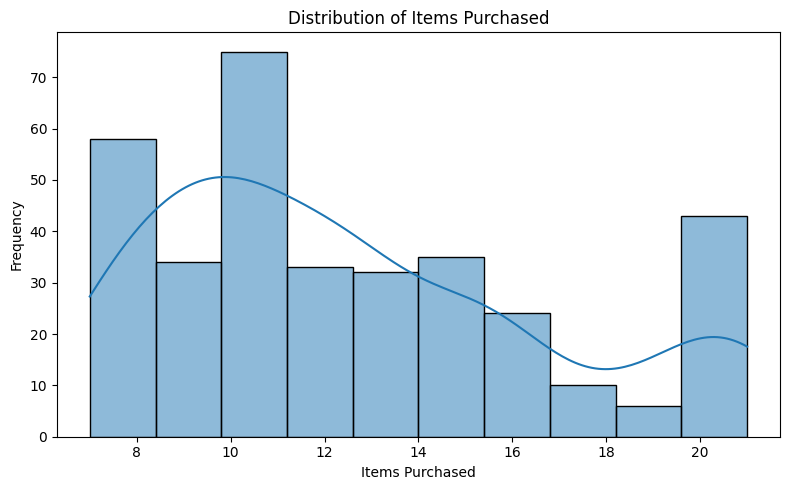


Average Rating
--------------------------------------------------
count    350.000000
mean       4.019143
std        0.580539
min        3.000000
25%        3.500000
50%        4.100000
75%        4.500000
max        4.900000
Name: Average Rating, dtype: float64


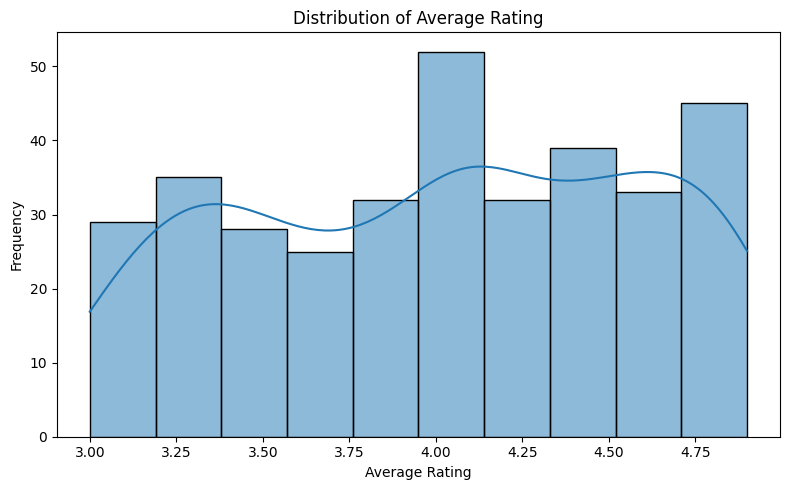


Days Since Last Purchase
--------------------------------------------------
count    350.000000
mean      26.588571
std       13.440813
min        9.000000
25%       15.000000
50%       23.000000
75%       38.000000
max       63.000000
Name: Days Since Last Purchase, dtype: float64


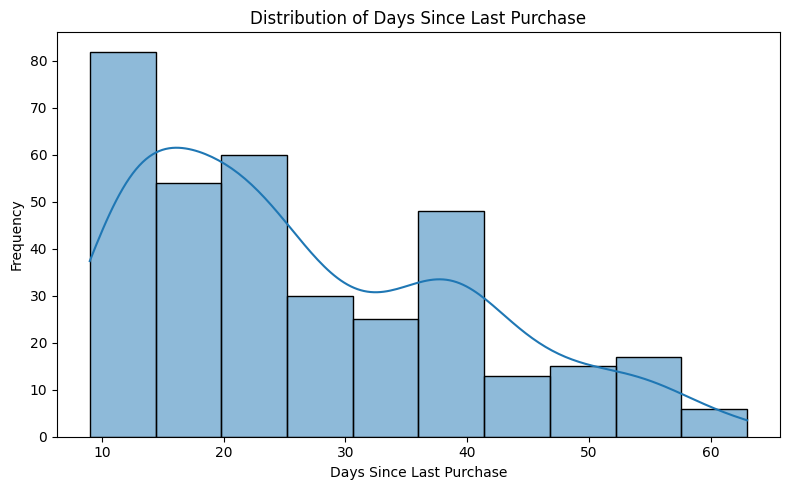

In [14]:
# Exploratory Data Analysis
#
# The EDA examines numerical distributions, categorical distributions,
# and relationships between numerical customer attributes.

# Numerical feature distributions

for column in numerical_features:
    print(f"\n{column}")
    print("-" * 50)
    print(data[column].describe())

    plt.figure(figsize=(8, 5))
    sns.histplot(data[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

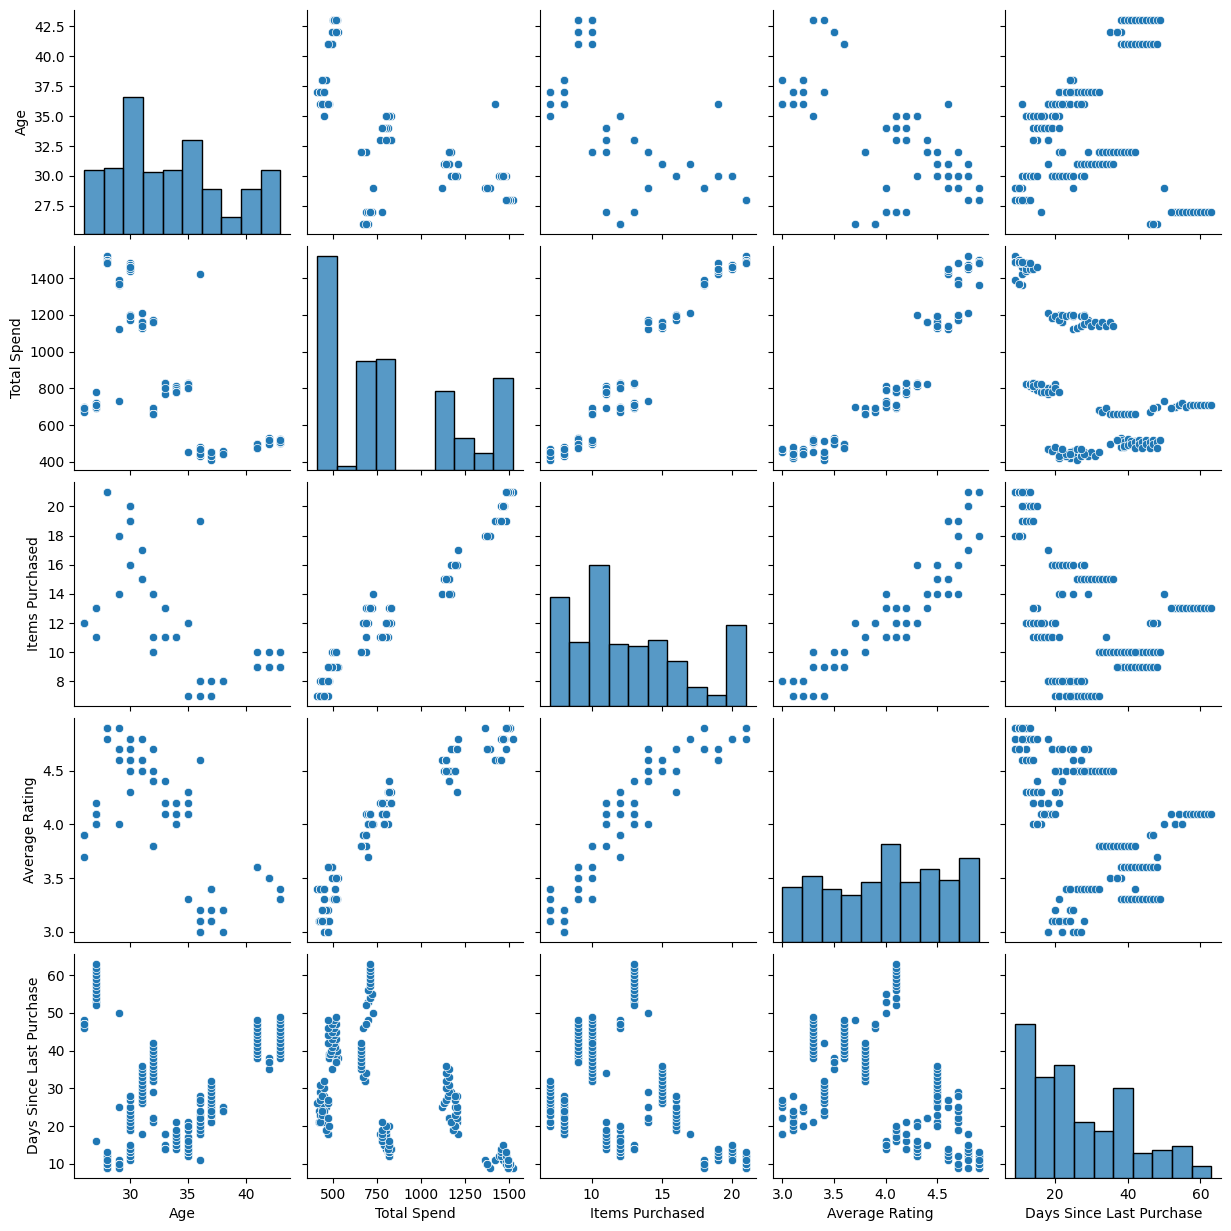

In [15]:
# Numerical feature relationships

sns.pairplot(
    data[numerical_features],
    diag_kind="hist"
)

plt.show()

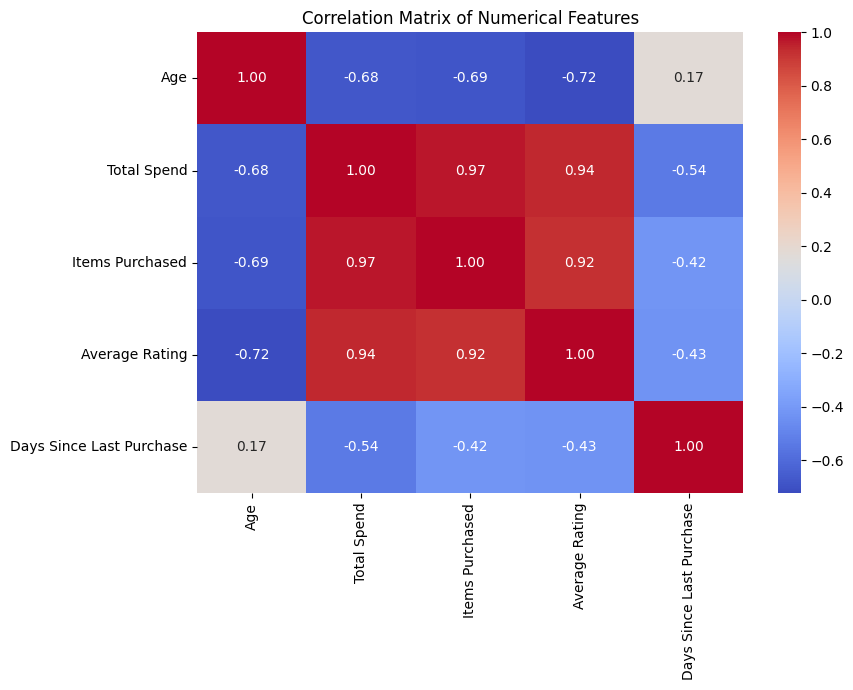

In [16]:
# Correlation between numerical features

correlation_matrix = data[numerical_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

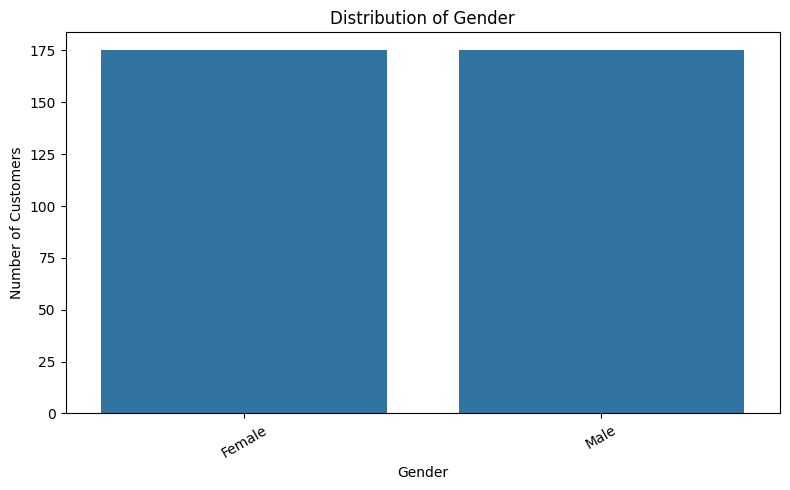

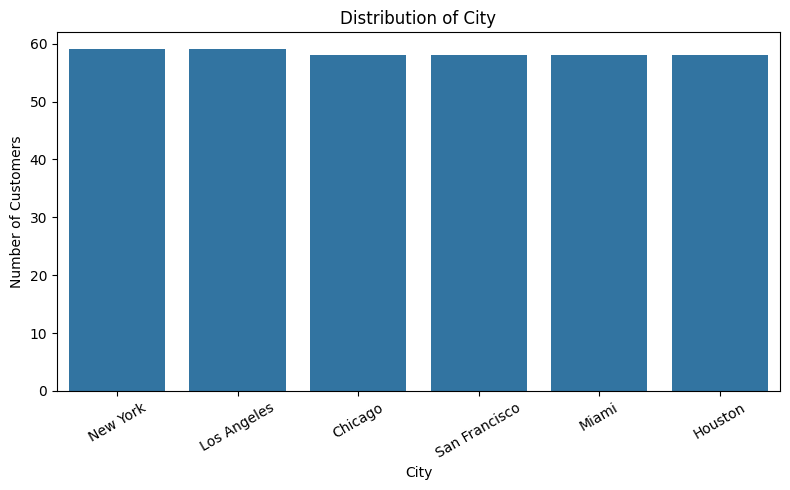

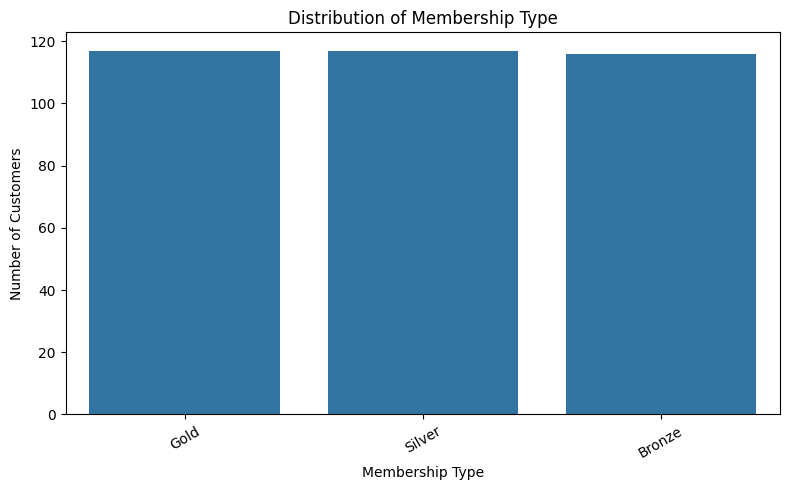

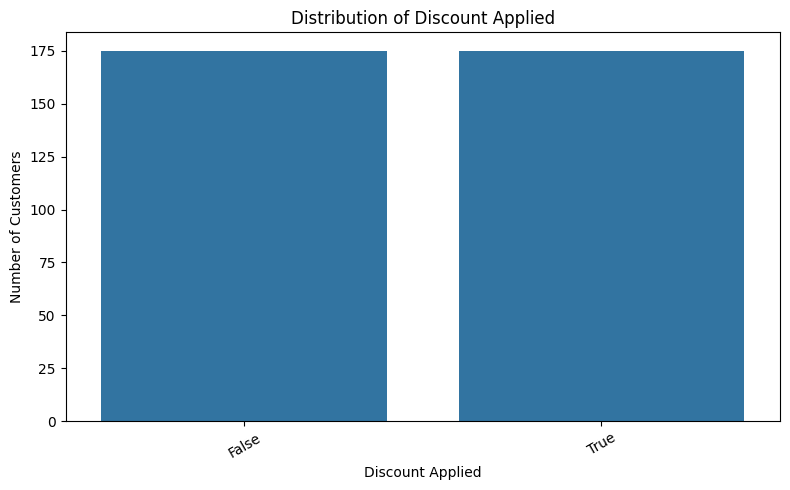

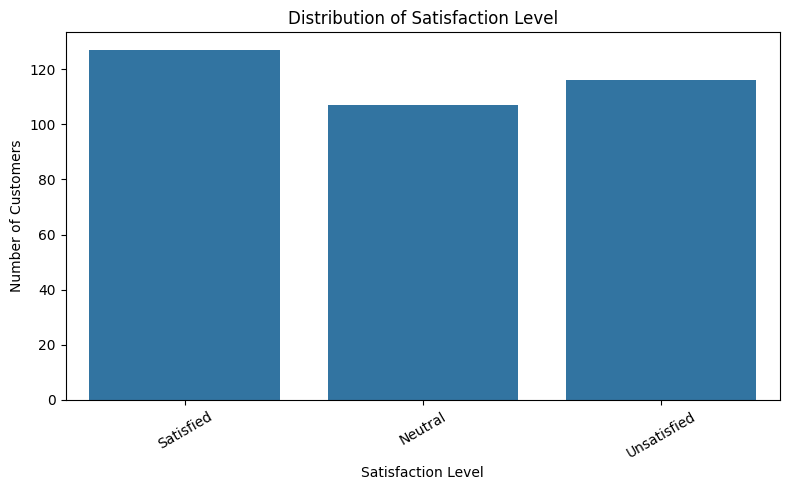

In [17]:
# Categorical feature distributions

for column in categorical_features:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=data,
        x=column
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 3. Baseline K-Means Clustering

A naive baseline: standardise the five numerical features and fit K-Means with `K=4`, chosen by visual inspection of the elbow curve below rather than by any formal criterion. This exists purely as a reference point for the more careful approach in Section 4 — it is not the final model.

In [18]:
# Baseline K-Means Clustering
#
# The baseline model uses the numerical features after standardisation.
# This provides a reference point for evaluating the improved approach.
# Standardise numerical features for the baseline model

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    data[numerical_features]
)

print("Scaled feature shape:", scaled_features.shape)

Scaled feature shape: (350, 5)


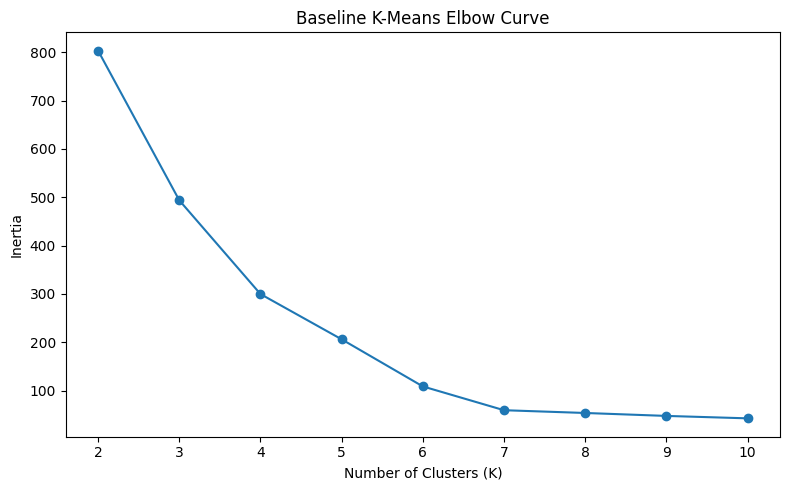

In [19]:
# Evaluate different numbers of clusters using the elbow method

baseline_inertia = []
baseline_k_values = range(2, 11)

for k in baseline_k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)
    baseline_inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(baseline_k_values, baseline_inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Baseline K-Means Elbow Curve")
plt.xticks(list(baseline_k_values))
plt.tight_layout()
plt.show()

In [20]:
# Fit the baseline K-Means model

baseline_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

baseline_clusters = baseline_kmeans.fit_predict(scaled_features)

baseline_data = data.copy()
baseline_data["Cluster"] = baseline_clusters

print("Baseline cluster sizes:")
print(baseline_data["Cluster"].value_counts().sort_index())

Baseline cluster sizes:
Cluster
0     58
1     59
2    116
3    117
Name: count, dtype: int64


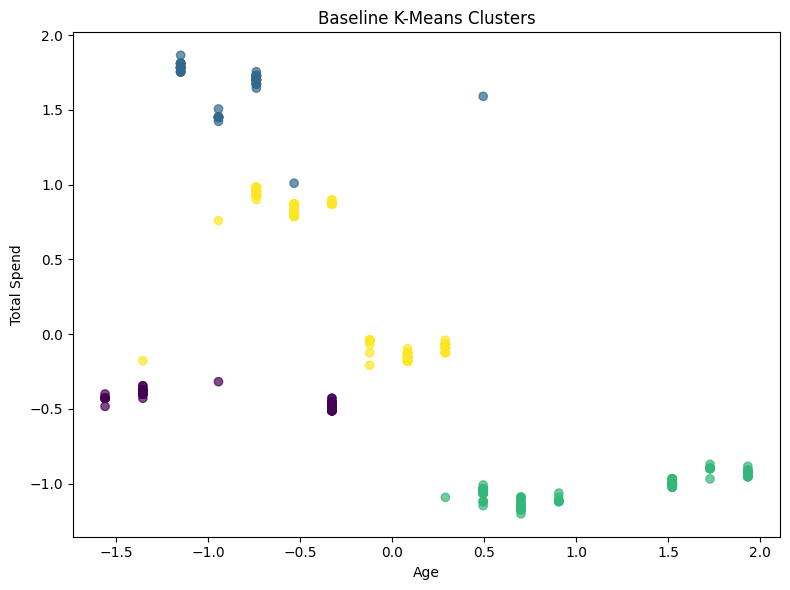

In [21]:
# Visualise the baseline clusters using the first two standardised features

plt.figure(figsize=(8, 6))

plt.scatter(
    scaled_features[:, 0],
    scaled_features[:, 1],
    c=baseline_clusters,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel(numerical_features[0])
plt.ylabel(numerical_features[1])
plt.title("Baseline K-Means Clusters")
plt.tight_layout()
plt.show()

In [22]:
# Evaluate baseline clustering using the silhouette score

baseline_silhouette = silhouette_score(
    scaled_features,
    baseline_clusters
)

print(f"Baseline silhouette score: {baseline_silhouette:.4f}")

Baseline silhouette score: 0.5626


In [23]:
# Baseline cluster profile

baseline_profile = (
    baseline_data
    .groupby("Cluster")[numerical_features]
    .mean()
    .round(2)
)

baseline_profile

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Cluster,,,,,
0,28.95,690.39,11.64,3.93,45.50
1,29.15,1455.55,19.95,4.81,11.29
2,39.36,473.39,8.49,3.32,31.61
3,32.43,983.34,13.44,4.35,19.95


In [24]:
# Baseline cluster sizes

baseline_cluster_sizes = (
    baseline_data["Cluster"]
    .value_counts()
    .sort_index()
)

baseline_cluster_sizes

Cluster
0     58
1     59
2    116
3    117
Name: count, dtype: int64

In [25]:
# Baseline modelling summary

print("Baseline model")
print("-" * 50)
print(f"Number of clusters: 4")
print(f"Silhouette score: {baseline_silhouette:.4f}")
print(f"Number of customers: {len(baseline_data)}")

Baseline model
--------------------------------------------------
Number of clusters: 4
Silhouette score: 0.5626
Number of customers: 350


## 4. Improved Clustering Methodology

The baseline treated cluster count and feature set as fixed choices. Here we instead compare three feature configurations — numerical + one-hot-encoded categoricals ("full-feature"), the same minus `City` ("behaviour-focused"), and numerical features only — and for each one select `K` by the highest silhouette score across `K = 2..10`, rather than guessing.

**Caveat on method.** One-hot-encoded categorical dummies and standardised continuous features are combined here and clustered with plain Euclidean-distance K-Means. This is a known weak point for mixed-type data — dummy columns can dominate the distance metric over continuous ones, especially when the categoricals are themselves highly separable (see Section 5a — that turns out to be exactly the case here). A more robust approach for genuinely mixed-type data would be K-Prototypes or a Gower-distance-based clustering method; the comparison below should be read with that limitation in mind.

In [26]:
# Improved Clustering Methodology
#
# The baseline model provides a reference point.
# We now evaluate alternative preprocessing and feature configurations
# before selecting the final clustering approach.
# Create a separate dataset for improved clustering

cluster_data = data.copy()

print("Clustering dataset shape:", cluster_data.shape)

Clustering dataset shape: (350, 10)


In [27]:
# Define numerical and categorical feature groups

numerical_features = [
    "Age",
    "Total Spend",
    "Items Purchased",
    "Average Rating",
    "Days Since Last Purchase"
]

categorical_features = [
    "Gender",
    "City",
    "Membership Type",
    "Discount Applied",
    "Satisfaction Level"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']
Categorical features: ['Gender', 'City', 'Membership Type', 'Discount Applied', 'Satisfaction Level']


In [28]:
# Preprocess numerical and categorical features
#
# Numerical features are standardised.
# Categorical features are one-hot encoded so that nominal categories
# are not treated as ordered numerical values.

full_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

X_full = full_preprocessor.fit_transform(cluster_data)

print("Processed feature shape:", X_full.shape)

Processed feature shape: (350, 21)


In [29]:
# Evaluate K-Means across different numbers of clusters

full_inertia = []
full_silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_full)

    full_inertia.append(kmeans.inertia_)
    full_silhouette_scores.append(
        silhouette_score(X_full, labels)
    )

evaluation_results = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Inertia": full_inertia,
    "Silhouette Score": full_silhouette_scores
})

evaluation_results.round(4)

,Number of Clusters,Inertia,Silhouette Score
0,2,1628.6846,0.4340
1,3,1029.4398,0.5011
2,4,671.1743,0.5811
3,5,401.7044,0.6859
4,6,132.3052,0.7871
5,7,81.1338,0.8029
6,8,65.6915,0.7987
7,9,59.6157,0.7601
8,10,54.5529,0.6940


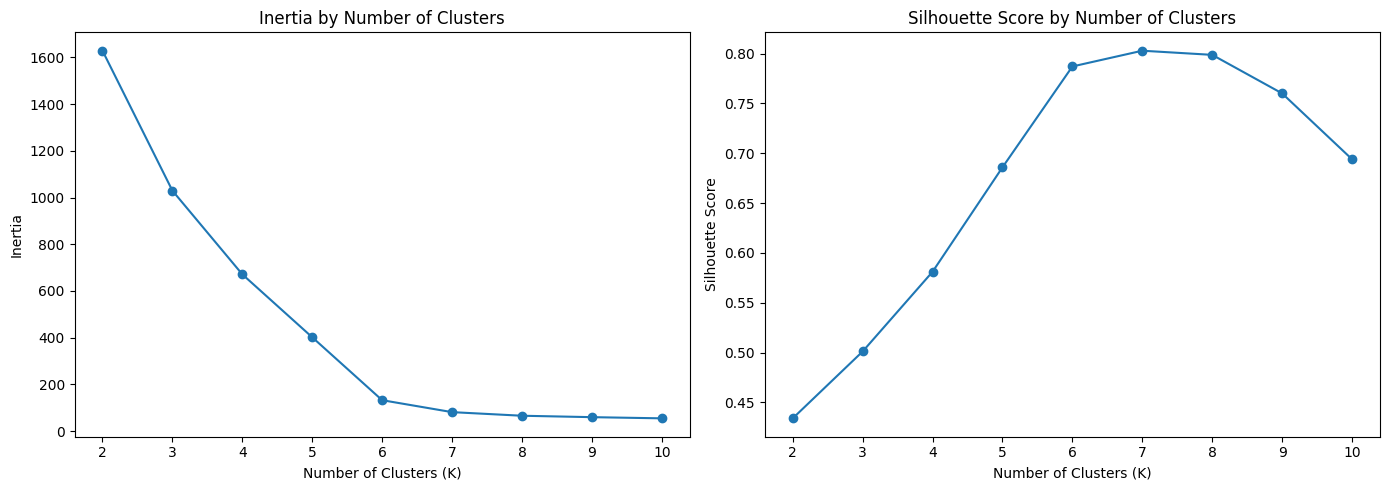

In [30]:
# Visualise inertia and silhouette scores

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    k_values,
    full_inertia,
    marker="o"
)
axes[0].set_title("Inertia by Number of Clusters")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_values))

axes[1].plot(
    k_values,
    full_silhouette_scores,
    marker="o"
)
axes[1].set_title("Silhouette Score by Number of Clusters")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()

In [31]:
# Select the candidate number of clusters

best_full_index = np.argmax(full_silhouette_scores)
best_full_k = list(k_values)[best_full_index]
best_full_score = full_silhouette_scores[best_full_index]

print(f"Highest silhouette score: {best_full_score:.4f}")
print(f"Candidate K: {best_full_k}")

Highest silhouette score: 0.8029
Candidate K: 7


In [32]:
# Fit the candidate full-feature model

full_kmeans = KMeans(
    n_clusters=best_full_k,
    random_state=42,
    n_init=10
)

full_labels = full_kmeans.fit_predict(X_full)

full_cluster_sizes = (
    pd.Series(full_labels)
    .value_counts()
    .sort_index()
)

print("Candidate cluster sizes:")
print(full_cluster_sizes)

Candidate cluster sizes:
0    58
1    59
2    59
3    34
4    58
5    58
6    24
Name: count, dtype: int64


In [33]:
# Profile the candidate clusters using numerical features

full_profile = cluster_data.copy()
full_profile["Cluster"] = full_labels

full_numerical_profile = (
    full_profile
    .groupby("Cluster")[numerical_features]
    .mean()
    .round(2)
)

full_numerical_profile

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Cluster,,,,,
0,36.71,446.89,7.57,3.19,22.76
1,30.71,1165.04,15.27,4.54,24.59
2,34.12,805.49,11.68,4.17,15.27
3,26.79,703.69,12.76,4.02,53.18
4,42.02,499.88,9.41,3.46,40.47
5,29.12,1459.77,20.00,4.81,11.17
6,32.00,671.55,10.04,3.80,34.62


In [34]:
# Inspect categorical composition of the candidate clusters

for column in categorical_features:
    print(f"\n{column}")
    print("-" * 50)

    profile = pd.crosstab(
        full_profile["Cluster"],
        full_profile[column],
        normalize="index"
    ) * 100

    print(profile.round(1))


Gender
--------------------------------------------------
Gender   Female   Male
Cluster               
0         100.0    0.0
1          98.3    1.7
2           0.0  100.0
3           2.9   97.1
4         100.0    0.0
5           0.0  100.0
6           0.0  100.0

City
--------------------------------------------------
City     Chicago  Houston  Los Angeles  Miami  New York  San Francisco
Cluster                                                               
0            0.0    100.0          0.0    0.0       0.0            0.0
1            0.0      0.0          0.0    0.0     100.0            0.0
2            0.0      0.0        100.0    0.0       0.0            0.0
3            0.0      0.0          0.0  100.0       0.0            0.0
4          100.0      0.0          0.0    0.0       0.0            0.0
5            0.0      0.0          0.0    0.0       0.0          100.0
6            0.0      0.0          0.0  100.0       0.0            0.0

Membership Type
---------------------

In [35]:
# Behaviour-focused clustering
#
# City is excluded to test whether clusters can be identified
# from customer behaviour and characteristics rather than location.

behaviour_categorical_features = [
    "Gender",
    "Membership Type",
    "Discount Applied",
    "Satisfaction Level"
]

behaviour_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            behaviour_categorical_features
        )
    ]
)

X_behaviour = behaviour_preprocessor.fit_transform(cluster_data)

print("Behaviour-focused feature shape:", X_behaviour.shape)

Behaviour-focused feature shape: (350, 15)


In [36]:
# Evaluate the behaviour-focused approach

behaviour_inertia = []
behaviour_silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_behaviour)

    behaviour_inertia.append(kmeans.inertia_)
    behaviour_silhouette_scores.append(
        silhouette_score(X_behaviour, labels)
    )

behaviour_evaluation = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Inertia": behaviour_inertia,
    "Silhouette Score": behaviour_silhouette_scores
})

behaviour_evaluation.round(4)

,Number of Clusters,Inertia,Silhouette Score
0,2,1395.5440,0.4399
1,3,854.4483,0.5094
2,4,554.6786,0.5785
3,5,343.2086,0.6728
4,6,132.3052,0.7621
5,7,81.1338,0.7822
6,8,65.6915,0.7831
7,9,59.6157,0.7475
8,10,54.2037,0.6886


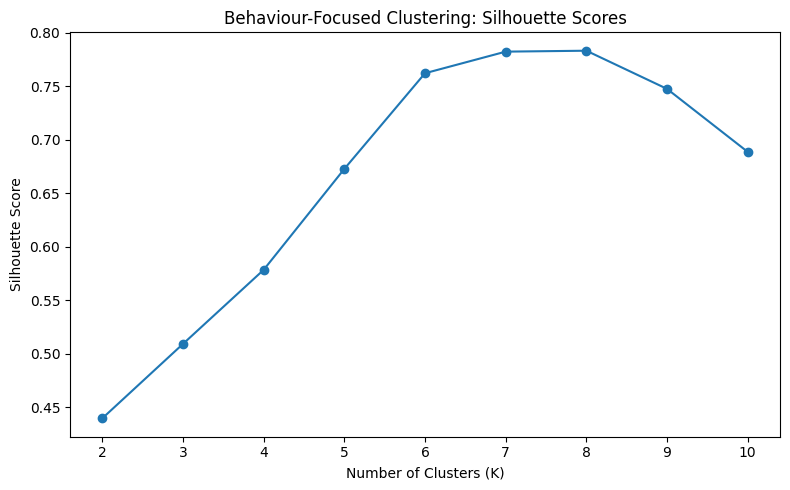

In [37]:
# Compare the behaviour-focused silhouette scores

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    behaviour_silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Behaviour-Focused Clustering: Silhouette Scores")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

In [38]:
# Select the candidate number of clusters for the behaviour-focused approach
#
# Chosen the same way as the full-feature model above: the K with the highest
# silhouette score, rather than reusing K=7 from the full-feature model without
# checking whether it's actually optimal for this feature set.

best_behaviour_index = np.argmax(behaviour_silhouette_scores)
behaviour_k = list(k_values)[best_behaviour_index]
best_behaviour_score = behaviour_silhouette_scores[best_behaviour_index]

print(f"Highest silhouette score: {best_behaviour_score:.4f}")
print(f"Candidate K: {behaviour_k}")

behaviour_kmeans = KMeans(
    n_clusters=behaviour_k,
    random_state=42,
    n_init=10
)

behaviour_labels = behaviour_kmeans.fit_predict(X_behaviour)

behaviour_profile = cluster_data.copy()
behaviour_profile["Cluster"] = behaviour_labels

print(
    f"\nBehaviour-focused K={behaviour_k} silhouette score:",
    f"{silhouette_score(X_behaviour, behaviour_labels):.4f}"
)

print("\nCluster sizes:")
print(
    behaviour_profile["Cluster"]
    .value_counts()
    .sort_index()
)

Highest silhouette score: 0.7831
Candidate K: 8

Behaviour-focused K=8 silhouette score: 0.7831

Cluster sizes:
Cluster
0    58
1    59
2    51
3    58
4    34
5    58
6    24
7     8
Name: count, dtype: int64


In [39]:
# Numerical-only behavioural clustering
#
# The final candidate uses only numerical customer attributes.
# This avoids imposing artificial structure on categorical variables
# and allows the segments to be defined directly by measurable behaviour.

numerical_features_only = [
    "Age",
    "Total Spend",
    "Items Purchased",
    "Average Rating",
    "Days Since Last Purchase"
]

numerical_preprocessor = StandardScaler()

X_numerical = numerical_preprocessor.fit_transform(
    cluster_data[numerical_features_only]
)

print("Numerical-only feature shape:", X_numerical.shape)

Numerical-only feature shape: (350, 5)


In [40]:
# Evaluate numerical-only clustering

numerical_inertia = []
numerical_silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_numerical)

    numerical_inertia.append(kmeans.inertia_)
    numerical_silhouette_scores.append(
        silhouette_score(X_numerical, labels)
    )

numerical_evaluation = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Inertia": numerical_inertia,
    "Silhouette Score": numerical_silhouette_scores
})

numerical_evaluation.round(4)

,Number of Clusters,Inertia,Silhouette Score
0,2,802.9840,0.4823
1,3,493.5771,0.4941
2,4,299.7407,0.5626
3,5,206.1428,0.5893
4,6,108.7418,0.6568
5,7,59.5340,0.7139
6,8,53.8151,0.6853
7,9,47.7392,0.6629
8,10,42.7280,0.6265


In [41]:
# Compare all clustering approaches

numerical_best_k = int(
    numerical_evaluation.loc[
        numerical_evaluation["Silhouette Score"].idxmax(),
        "Number of Clusters"
    ]
)

# Calculate the silhouette score for the selected full-feature model
full_best_silhouette = silhouette_score(
    X_full,
    full_labels
)

# Calculate the silhouette score for the selected behaviour-focused model
behaviour_best_silhouette = silhouette_score(
    X_behaviour,
    behaviour_labels
)

# Calculate the silhouette score for the numerical-only model
numerical_best_silhouette = numerical_evaluation[
    "Silhouette Score"
].max()

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline K=4",
        "Full-feature K-Means",
        "Behaviour-focused",
        "Numerical-only"
    ],
    "Selected K": [
        4,
        best_full_k,
        behaviour_k,
        numerical_best_k
    ],
    "Best Silhouette Score": [
        baseline_silhouette,
        full_best_silhouette,
        behaviour_best_silhouette,
        numerical_best_silhouette
    ]
})

model_comparison.round(4)

,Model,Selected K,Best Silhouette Score
0,Baseline K=4,4,0.5626
1,Full-feature K-Means,7,0.8029
2,Behaviour-focused,8,0.7831
3,Numerical-only,7,0.7139


## 5. Final Model: Numerical-Only Segmentation

In [42]:
# Identify the numerical-only optimum

numerical_best_row = numerical_evaluation.loc[
    numerical_evaluation["Silhouette Score"].idxmax()
]

numerical_best_k = int(numerical_best_row["Number of Clusters"])
numerical_best_silhouette = numerical_best_row["Silhouette Score"]

print("Numerical-only best K:", numerical_best_k)
print(
    "Numerical-only silhouette:",
    round(numerical_best_silhouette, 4)
)

Numerical-only best K: 7
Numerical-only silhouette: 0.7139


In [43]:
# Fit the candidate final numerical-only model

final_k = numerical_best_k

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_numerical)

cluster_data["Cluster"] = final_labels

print("Final candidate number of clusters:", final_k)
print(
    "Final candidate silhouette score:",
    round(silhouette_score(X_numerical, final_labels), 4)
)

Final candidate number of clusters: 7
Final candidate silhouette score: 0.7139


In [44]:
# Examine the size of each final cluster

cluster_sizes = (
    cluster_data["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customer Count")
    .to_frame()
)

cluster_sizes["Percentage"] = (
    cluster_sizes["Customer Count"]
    / len(cluster_data)
    * 100
)

cluster_sizes.round(2)

,Customer Count,Percentage
Cluster,,
0,58,16.57
1,59,16.86
2,58,16.57
3,34,9.71
4,58,16.57
5,59,16.86
6,24,6.86


In [45]:
# Create behavioural profiles for the final clusters

cluster_profiles = (
    cluster_data
    .groupby("Cluster")
    .agg({
        "Age": "mean",
        "Total Spend": "mean",
        "Items Purchased": "mean",
        "Average Rating": "mean",
        "Days Since Last Purchase": "mean"
    })
    .round(2)
)

cluster_profiles

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Cluster,,,,,
0,36.71,446.89,7.57,3.19,22.76
1,34.12,805.49,11.68,4.17,15.27
2,29.12,1459.77,20.00,4.81,11.17
3,26.79,703.69,12.76,4.02,53.18
4,42.02,499.88,9.41,3.46,40.47
5,30.71,1165.04,15.27,4.54,24.59
6,32.00,671.55,10.04,3.80,34.62


In [46]:
# Add cluster size information to the behavioural profiles

cluster_profiles["Customer Count"] = (
    cluster_data["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_profiles["Percentage"] = (
    cluster_profiles["Customer Count"]
    / len(cluster_data)
    * 100
)

cluster_profiles.round(2)

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase,Customer Count,Percentage
Cluster,,,,,,,
0,36.71,446.89,7.57,3.19,22.76,58,16.57
1,34.12,805.49,11.68,4.17,15.27,59,16.86
2,29.12,1459.77,20.00,4.81,11.17,58,16.57
3,26.79,703.69,12.76,4.02,53.18,34,9.71
4,42.02,499.88,9.41,3.46,40.47,58,16.57
5,30.71,1165.04,15.27,4.54,24.59,59,16.86
6,32.00,671.55,10.04,3.80,34.62,24,6.86


In [47]:
# Descriptive categorical characteristics of each numerical cluster

categorical_profiles = (
    cluster_data
    .groupby("Cluster")
    .agg({
        "Gender": lambda x: x.mode().iloc[0],
        "City": lambda x: x.mode().iloc[0],
        "Membership Type": lambda x: x.mode().iloc[0],
        "Discount Applied": lambda x: x.mode().iloc[0],
        "Satisfaction Level": lambda x: x.mode().iloc[0]
    })
)

categorical_profiles

,Gender,City,Membership Type,Discount Applied,Satisfaction Level
Cluster,,,,,
0,Female,Houston,Bronze,False,Neutral
1,Male,Los Angeles,Silver,False,Neutral
2,Male,San Francisco,Gold,False,Satisfied
3,Male,Miami,Silver,True,Unsatisfied
4,Female,Chicago,Bronze,True,Unsatisfied
5,Female,New York,Gold,True,Satisfied
6,Male,Miami,Silver,True,Unsatisfied


In [48]:
# Combine numerical and categorical cluster profiles

final_cluster_profiles = cluster_profiles.join(
    categorical_profiles
)

final_cluster_profiles.round(2)

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase,Customer Count,Percentage,Gender,City,Membership Type,Discount Applied,Satisfaction Level
Cluster,,,,,,,,,,,,
0,36.71,446.89,7.57,3.19,22.76,58,16.57,Female,Houston,Bronze,False,Neutral
1,34.12,805.49,11.68,4.17,15.27,59,16.86,Male,Los Angeles,Silver,False,Neutral
2,29.12,1459.77,20.00,4.81,11.17,58,16.57,Male,San Francisco,Gold,False,Satisfied
3,26.79,703.69,12.76,4.02,53.18,34,9.71,Male,Miami,Silver,True,Unsatisfied
4,42.02,499.88,9.41,3.46,40.47,58,16.57,Female,Chicago,Bronze,True,Unsatisfied
5,30.71,1165.04,15.27,4.54,24.59,59,16.86,Female,New York,Gold,True,Satisfied
6,32.00,671.55,10.04,3.80,34.62,24,6.86,Male,Miami,Silver,True,Unsatisfied


In [49]:
# Examine city distribution within each numerical cluster

city_distribution = pd.crosstab(
    cluster_data["Cluster"],
    cluster_data["City"],
    normalize="index"
) * 100

city_distribution.round(2)

City,Chicago,Houston,Los Angeles,Miami,New York,San Francisco
Cluster,,,,,,
0,0.0,100.0,0.0,0.0,0.0,0.0
1,0.0,0.0,100.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,100.0
3,0.0,0.0,0.0,100.0,0.0,0.0
4,100.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,100.0,0.0
6,0.0,0.0,0.0,100.0,0.0,0.0


In [50]:
# Quantify the dominant city within each cluster

city_concentration = (
    cluster_data
    .groupby("Cluster")["City"]
    .agg(
        Dominant_City=lambda x: x.value_counts().index[0],
        Dominant_City_Percentage=lambda x: x.value_counts(normalize=True).iloc[0] * 100
    )
)

city_concentration.round(2)

,Dominant_City,Dominant_City_Percentage
Cluster,,
0,Houston,100.0
1,Los Angeles,100.0
2,San Francisco,100.0
3,Miami,100.0
4,Chicago,100.0
5,New York,100.0
6,Miami,100.0


In [51]:
# Create a clean summary table for the seven customer segments

segment_summary = final_cluster_profiles.copy()

segment_summary["Segment Size (%)"] = (
    segment_summary["Percentage"].round(2)
)

segment_summary

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase,Customer Count,Percentage,Gender,City,Membership Type,Discount Applied,Satisfaction Level,Segment Size (%)
Cluster,,,,,,,,,,,,,
0,36.71,446.89,7.57,3.19,22.76,58,16.571429,Female,Houston,Bronze,False,Neutral,16.57
1,34.12,805.49,11.68,4.17,15.27,59,16.857143,Male,Los Angeles,Silver,False,Neutral,16.86
2,29.12,1459.77,20.00,4.81,11.17,58,16.571429,Male,San Francisco,Gold,False,Satisfied,16.57
3,26.79,703.69,12.76,4.02,53.18,34,9.714286,Male,Miami,Silver,True,Unsatisfied,9.71
4,42.02,499.88,9.41,3.46,40.47,58,16.571429,Female,Chicago,Bronze,True,Unsatisfied,16.57
5,30.71,1165.04,15.27,4.54,24.59,59,16.857143,Female,New York,Gold,True,Satisfied,16.86
6,32.00,671.55,10.04,3.80,34.62,24,6.857143,Male,Miami,Silver,True,Unsatisfied,6.86


In [52]:
# Compare each cluster's numerical characteristics with the overall dataset

overall_means = cluster_data[numerical_features_only].mean()

cluster_deviation = cluster_profiles[numerical_features_only].subtract(
    overall_means
).round(2)

cluster_deviation

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Cluster,,,,,
0,3.11,-398.49,-5.03,-0.83,-3.83
1,0.52,-39.89,-0.92,0.15,-11.32
2,-4.48,614.39,7.40,0.79,-15.42
3,-6.81,-141.69,0.16,0.00,26.59
4,8.42,-345.50,-3.19,-0.56,13.88
5,-2.89,319.66,2.67,0.52,-2.00
6,-1.60,-173.83,-2.56,-0.22,8.03


In [53]:
# Create a standardized scorecard for interpreting cluster behaviour

from sklearn.preprocessing import StandardScaler

scorecard_features = [
    "Total Spend",
    "Items Purchased",
    "Average Rating",
    "Days Since Last Purchase"
]

scorecard = cluster_profiles[scorecard_features].copy()

scorecard_z = pd.DataFrame(
    StandardScaler().fit_transform(scorecard),
    index=scorecard.index,
    columns=scorecard.columns
).round(2)

scorecard_z

,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Cluster,,,,
0,-1.10,-1.25,-1.53,-0.45
1,-0.05,-0.18,0.32,-0.99
2,1.88,1.97,1.53,-1.29
3,-0.35,0.10,0.04,1.78
4,-0.95,-0.77,-1.02,0.85
5,1.01,0.75,1.02,-0.31
6,-0.44,-0.61,-0.37,0.42


In [54]:
# Assign descriptive business labels to the seven numerical clusters
#
# Cluster 3 is labelled "At-Risk" rather than "Active" because it has the *highest*
# Days Since Last Purchase of all seven clusters (53.18, vs an overall mean of 26.59)
# and below-average Total Spend. The original label ("At-Risk Active-Value") called
# this group "Active" despite it being the least recently active segment in the
# dataset -- the label below is corrected to match the underlying numbers instead.

segment_labels = {
    0: "Low-Value Neutral Customers",
    1: "Active Mid-Value Customers",
    2: "High-Value Engaged Customers",
    3: "At-Risk Average-Value Customers",
    4: "Low-Value Inactive Customers",
    5: "High-Value Satisfied Customers",
    6: "Low-Value At-Risk Customers"
}

cluster_data["Segment"] = cluster_data["Cluster"].map(segment_labels)

segment_label_summary = (
    cluster_data[["Cluster", "Segment"]]
    .drop_duplicates()
    .sort_values("Cluster")
)

segment_label_summary

,Cluster,Segment
5,0,Low-Value Neutral Customers
1,1,Active Mid-Value Customers
3,2,High-Value Engaged Customers
4,3,At-Risk Average-Value Customers
2,4,Low-Value Inactive Customers
0,5,High-Value Satisfied Customers
10,6,Low-Value At-Risk Customers


## 5a. Why Are the Silhouette Scores So High? Checking for a City Confound

Silhouette scores of 0.71-0.80 (Section 4) are unusually high for real customer behavioural data -- worth checking rather than accepting at face value. If `City`, `Membership Type`, etc. are themselves near-deterministic functions of the numerical features, any clustering on those numerical features will trivially "rediscover" `City`, regardless of feature set or algorithm, and the resulting segments would not represent newly-discovered behavioural structure.

In [55]:
# Check whether the numerical features are actually independent of City

for column in numerical_features:
    city_ranges = (
        cluster_data
        .groupby("City")[column]
        .agg(["min", "max"])
        .sort_values("min")
    )
    print(f"\n{column} range by City:")
    print(city_ranges)


Age range by City:
               min  max
City                   
Miami           26   32
Los Angeles     27   35
San Francisco   28   36
New York        29   32
Houston         35   38
Chicago         41   43

Total Spend range by City:
                   min     max
City                          
Houston         410.80   480.5
Chicago         475.25   530.4
Miami           660.30   730.4
Los Angeles     770.20   830.9
New York       1120.20  1210.6
San Francisco  1360.20  1520.1

Items Purchased range by City:
               min  max
City                   
Houston          7    8
Chicago          9   10
Miami           10   14
Los Angeles     11   13
New York        14   17
San Francisco   18   21

Average Rating range by City:
               min  max
City                   
Houston        3.0  3.4
Chicago        3.3  3.6
Miami          3.7  4.1
Los Angeles    4.0  4.4
New York       4.3  4.8
San Francisco  4.6  4.9

Days Since Last Purchase range by City:
               min  max


`Total Spend`, `Items Purchased` and `Average Rating` fall into **non-overlapping** bands by `City`, with sizeable gaps between cities (e.g. `Total Spend` jumps from a max of 530.4 in the Bronze-tier cities to a min of 660.3 in the next tier -- a gap no real, continuously-distributed customer population would show). `Age` and `Days Since Last Purchase` are more loosely banded but still ranked in the same city order. In other words, `City` is not independent of the clustering features here -- it's very nearly a re-encoding of them. `Membership Type` is a deterministic function of `City` with zero exceptions across all 350 rows, and `Gender` / `Discount Applied` are deterministic for all but 2 rows.

**Consequence:** every clustering approach in Section 4, regardless of feature set, should be expected to reconstruct `City`-based groups. That's exactly what happens -- but it's worth checking whether *anything else* survives once city membership is accounted for.

In [56]:
# Do the seven segments add information beyond City + Membership Type + Discount Applied,
# or do they only recover it? Check whether any City/Membership/Discount group got split
# across more than one of our seven segments.

city_membership_groups = (
    cluster_data
    .groupby(["City", "Membership Type", "Discount Applied"])["Cluster"]
    .nunique()
    .sort_values(ascending=False)
)

print("Number of distinct segments found within each City/Membership/Discount group:")
print(city_membership_groups)

split_groups = city_membership_groups[city_membership_groups > 1].index

if len(split_groups) > 0:
    city, membership, discount = split_groups[0]
    subset = cluster_data[
        (cluster_data["City"] == city) &
        (cluster_data["Membership Type"] == membership) &
        (cluster_data["Discount Applied"] == discount)
    ]
    print(
        f"\nThe only group split across multiple segments: "
        f"{city} / {membership} / Discount Applied={discount}"
    )
    print(
        subset
        .groupby("Segment")[["Age", "Days Since Last Purchase"]]
        .agg(["min", "max", "mean"])
        .round(2)
    )
else:
    print("\nEvery City/Membership/Discount group maps to exactly one segment.")

Number of distinct segments found within each City/Membership/Discount group:
City           Membership Type  Discount Applied
Miami          Silver           True                2
Chicago        Bronze           True                1
Houston        Bronze           False               1
Los Angeles    Silver           False               1
New York       Gold             True                1
San Francisco  Gold             False               1
Name: Cluster, dtype: int64

The only group split across multiple segments: Miami / Silver / Discount Applied=True
                                Age            Days Since Last Purchase      \
                                min max   mean                      min max   
Segment                                                                       
At-Risk Average-Value Customers  26  29  26.79                       46  63   
Low-Value At-Risk Customers      32  32  32.00                       32  42   

                                      

Six of the seven segments map exactly one-to-one onto a `City` x `Membership Type` x `Discount Applied` combination -- clustering on the five numerical features alone reconstructs `City` even though `City` was never in the feature set. Only one group is split across more than one segment, and it's split along `Age` and `Days Since Last Purchase` -- a genuine within-city distinction the categorical columns don't capture on their own.

**Bottom line:** roughly 6 of the 7 "behavioural segments" produced by this analysis are functionally equivalent to `groupby("City")`. The one exception is real, if narrow. Read the segment profiles below as *"city tier, plus one age/recency-based split within a single city"* rather than as seven independently-discovered behavioural personas -- the segment labels themselves don't make this explicit, and they should be read with this caveat in mind.

## 6. Segment Comparison Visualisations

In [57]:
# Verify final segment sizes

final_segment_sizes = (
    cluster_data
    .groupby(["Cluster", "Segment"])
    .size()
    .reset_index(name="Customer Count")
)

final_segment_sizes["Percentage"] = (
    final_segment_sizes["Customer Count"]
    / len(cluster_data)
    * 100
)

final_segment_sizes.round(2)

,Cluster,Segment,Customer Count,Percentage
0,0,Low-Value Neutral Customers,58,16.57
1,1,Active Mid-Value Customers,59,16.86
2,2,High-Value Engaged Customers,58,16.57
3,3,At-Risk Average-Value Customers,34,9.71
4,4,Low-Value Inactive Customers,58,16.57
5,5,High-Value Satisfied Customers,59,16.86
6,6,Low-Value At-Risk Customers,24,6.86


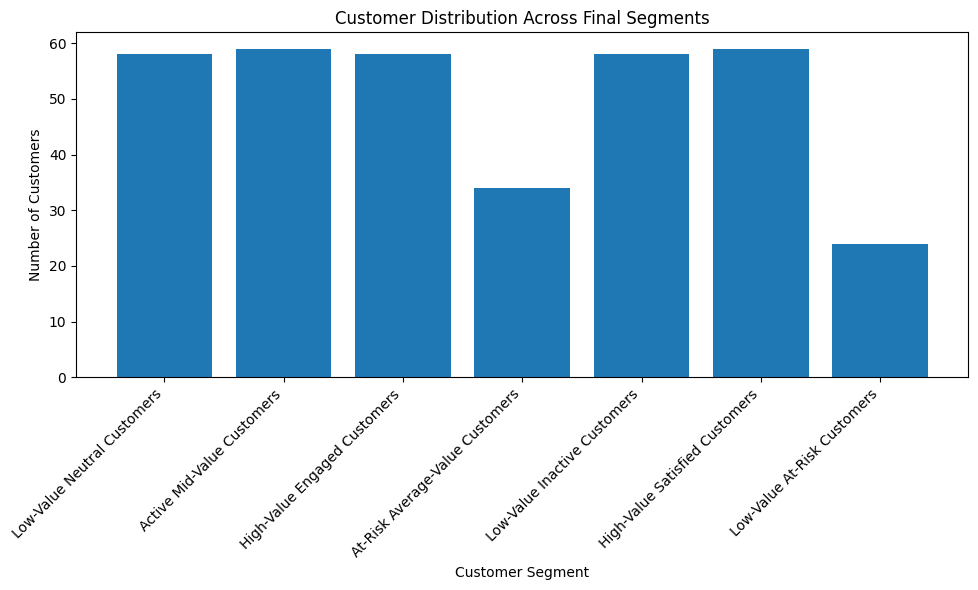

In [58]:
# Visualise customer distribution across the final segments

segment_counts = (
    cluster_data["Segment"]
    .value_counts()
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution Across Final Segments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

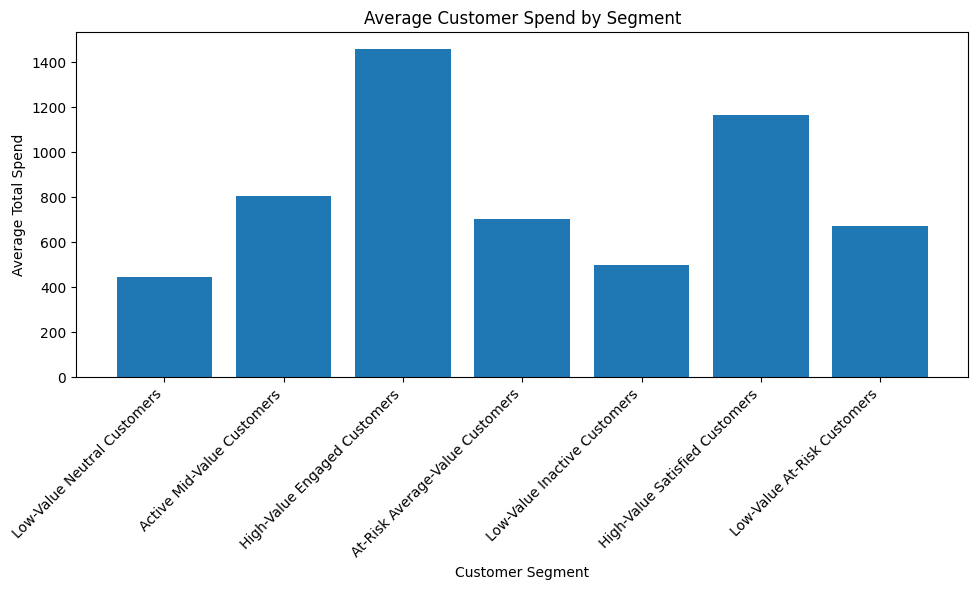

In [59]:
# Compare average customer spend across the final segments

segment_spend = (
    cluster_data
    .groupby("Segment")["Total Spend"]
    .mean()
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_spend.index,
    segment_spend.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Total Spend")
plt.title("Average Customer Spend by Segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

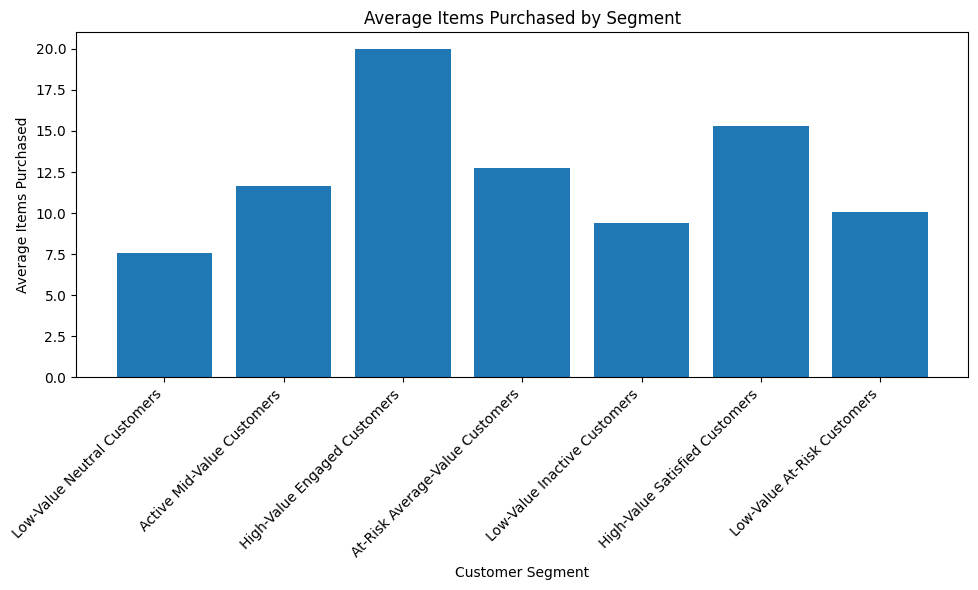

In [60]:
# Compare average items purchased across the final segments

segment_items = (
    cluster_data
    .groupby("Segment")["Items Purchased"]
    .mean()
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_items.index,
    segment_items.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Items Purchased")
plt.title("Average Items Purchased by Segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

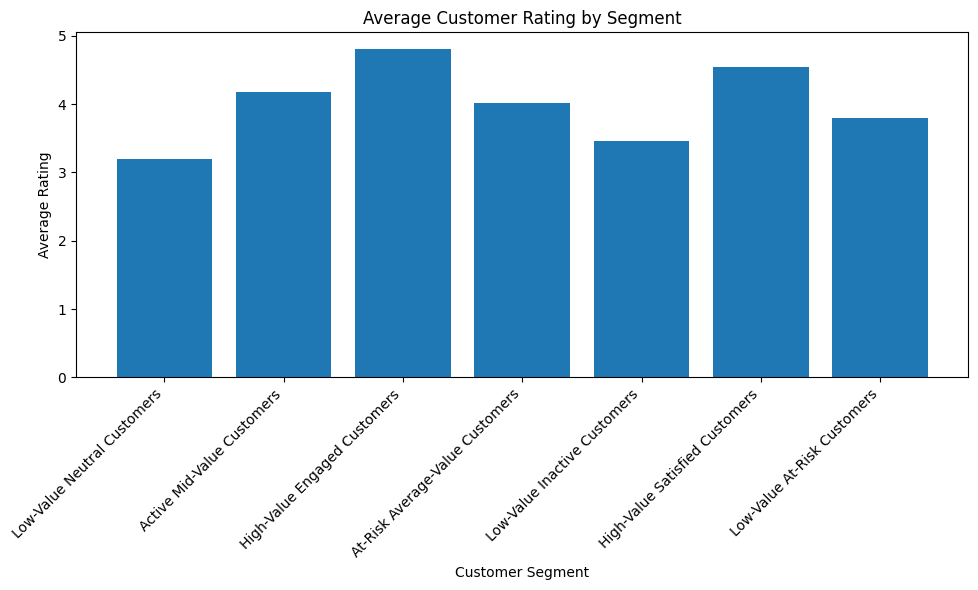

In [61]:
# Compare average customer rating across the final segments

segment_rating = (
    cluster_data
    .groupby("Segment")["Average Rating"]
    .mean()
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_rating.index,
    segment_rating.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Rating")
plt.title("Average Customer Rating by Segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

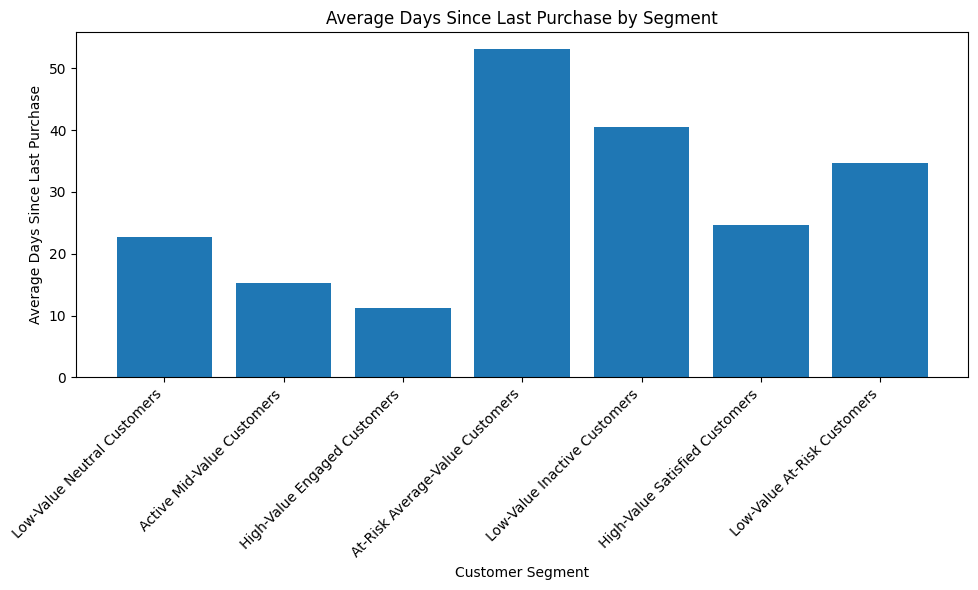

In [62]:
# Compare purchase recency across the final segments

segment_recency = (
    cluster_data
    .groupby("Segment")["Days Since Last Purchase"]
    .mean()
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_recency.index,
    segment_recency.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Days Since Last Purchase")
plt.title("Average Days Since Last Purchase by Segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

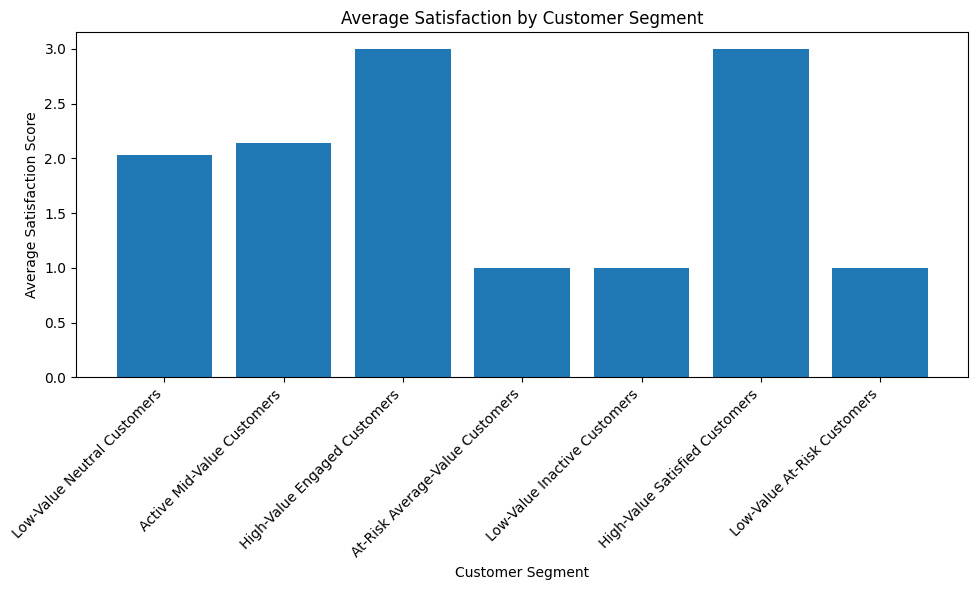

In [63]:
# Convert satisfaction levels to an ordered numeric scale for analysis

satisfaction_mapping = {
    "Unsatisfied": 1,
    "Neutral": 2,
    "Satisfied": 3
}

cluster_data["Satisfaction Score"] = (
    cluster_data["Satisfaction Level"]
    .map(satisfaction_mapping)
)

segment_satisfaction = (
    cluster_data
    .groupby("Segment")["Satisfaction Score"]
    .mean()
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_satisfaction.index,
    segment_satisfaction.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Satisfaction Score")
plt.title("Average Satisfaction by Customer Segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

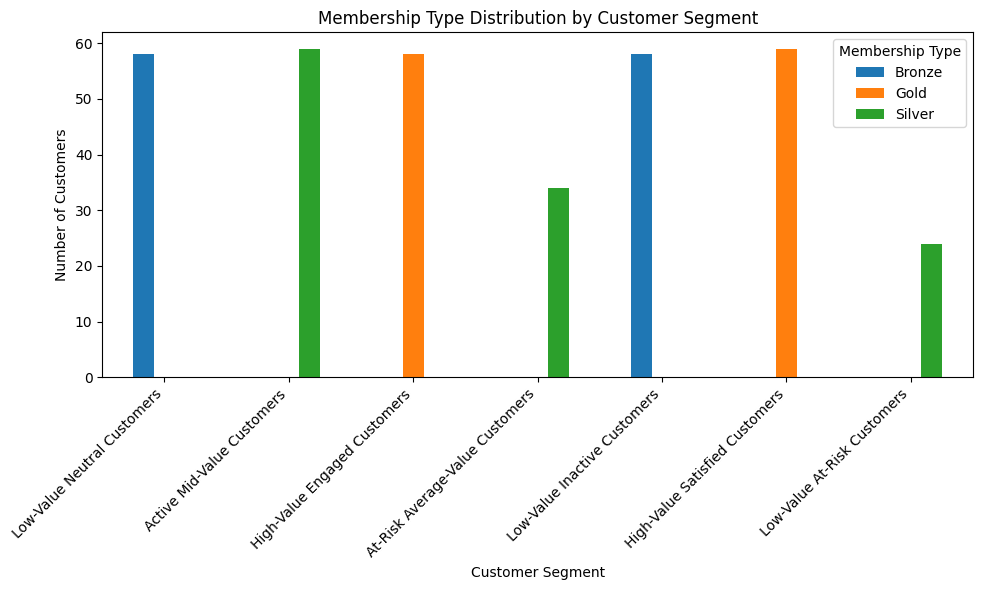

In [64]:
# Compare membership type composition across the final segments

membership_segment = pd.crosstab(
    cluster_data["Segment"],
    cluster_data["Membership Type"]
)

membership_segment = membership_segment.reindex(segment_labels.values())

membership_segment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Membership Type Distribution by Customer Segment")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Membership Type")
plt.tight_layout()
plt.show()

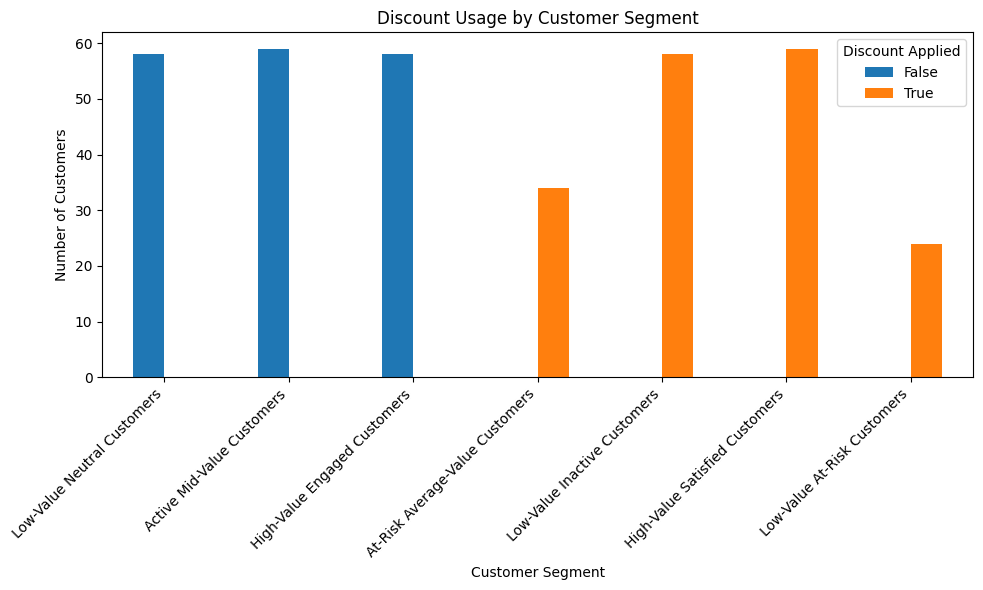

In [65]:
# Compare discount usage across the final segments

discount_segment = pd.crosstab(
    cluster_data["Segment"],
    cluster_data["Discount Applied"]
)

discount_segment = discount_segment.reindex(segment_labels.values())

discount_segment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Discount Usage by Customer Segment")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Discount Applied")
plt.tight_layout()
plt.show()

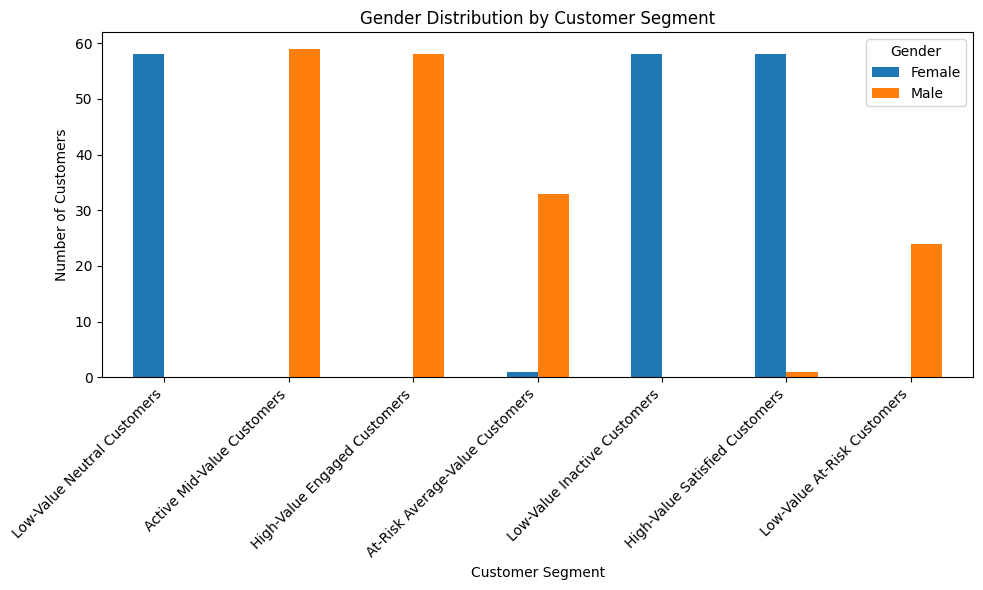

In [66]:
# Compare gender composition across the final segments

gender_segment = pd.crosstab(
    cluster_data["Segment"],
    cluster_data["Gender"]
)

gender_segment = gender_segment.reindex(segment_labels.values())

gender_segment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Gender Distribution by Customer Segment")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

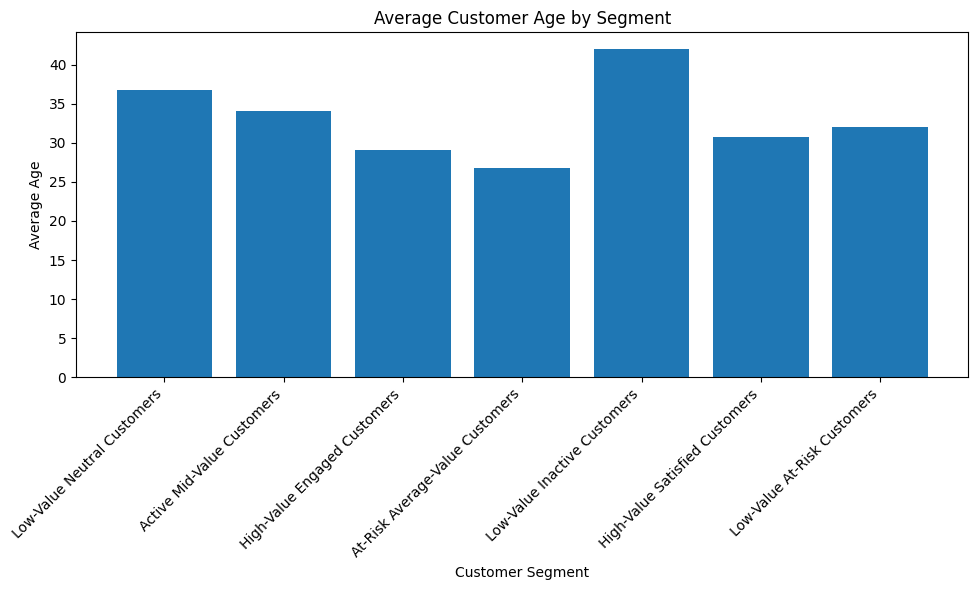

In [67]:
# Compare average customer age across the final segments

segment_age = (
    cluster_data
    .groupby("Segment")["Age"]
    .mean()
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_age.index,
    segment_age.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Age")
plt.title("Average Customer Age by Segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

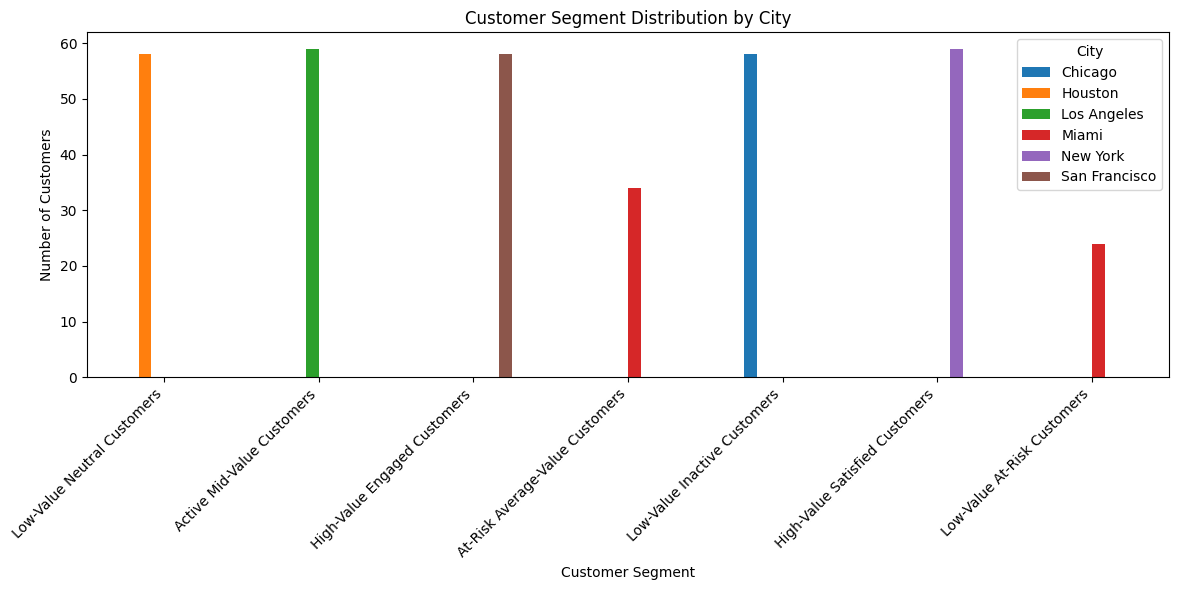

In [68]:
# Compare customer segment distribution across cities

city_segment = pd.crosstab(
    cluster_data["Segment"],
    cluster_data["City"]
)

city_segment = city_segment.reindex(segment_labels.values())

city_segment.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segment Distribution by City")
plt.xticks(rotation=45, ha="right")
plt.legend(title="City")
plt.tight_layout()
plt.show()

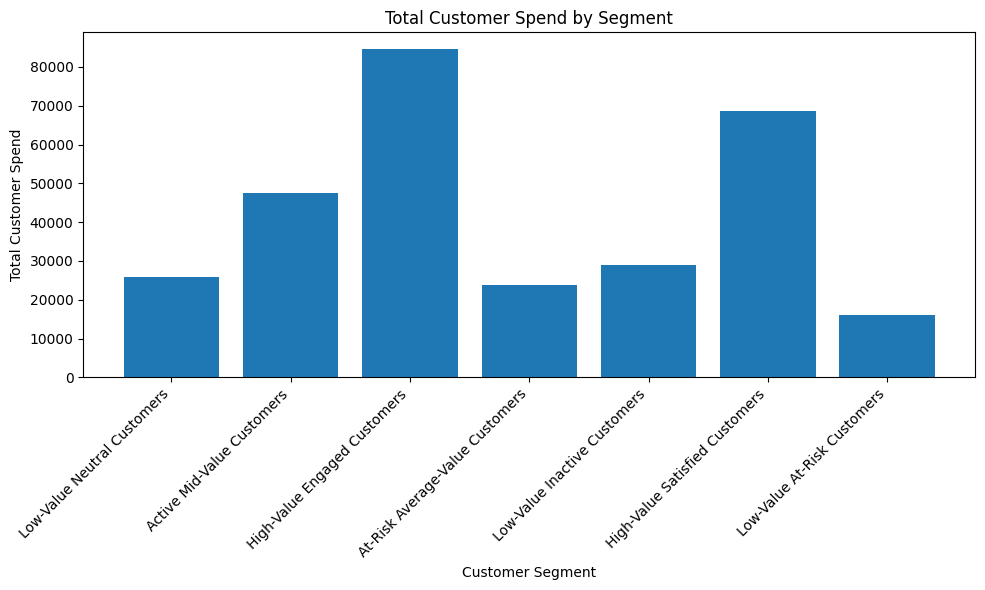

In [69]:
# Compare total customer spend contributed by each final segment

segment_total_spend = (
    cluster_data
    .groupby("Segment")["Total Spend"]
    .sum()
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_total_spend.index,
    segment_total_spend.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Total Customer Spend")
plt.title("Total Customer Spend by Segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

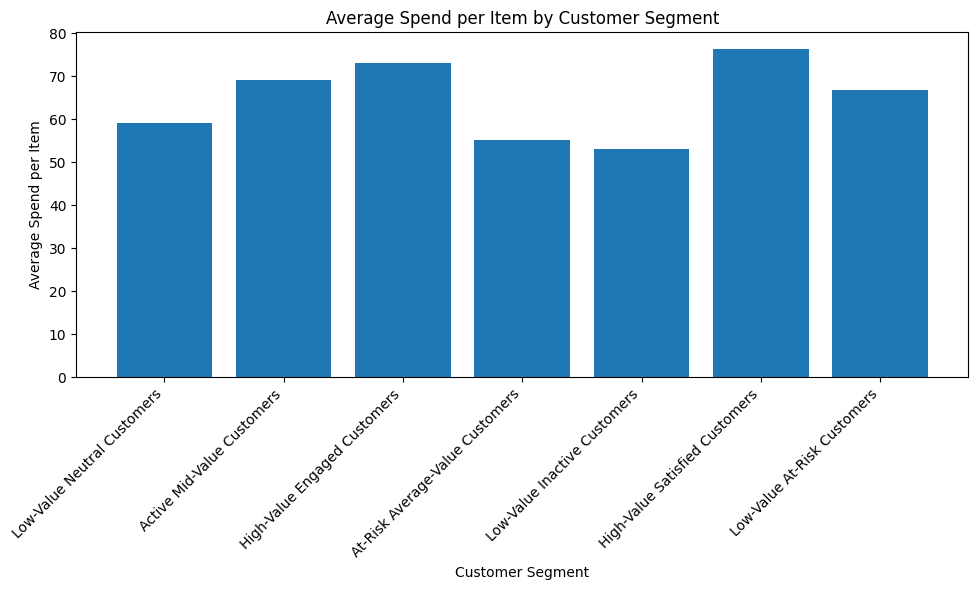

In [70]:
# Calculate average spend per item for each final segment

cluster_data["Spend per Item"] = (
    cluster_data["Total Spend"] /
    cluster_data["Items Purchased"]
)

segment_spend_per_item = (
    cluster_data
    .groupby("Segment")["Spend per Item"]
    .mean()
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_spend_per_item.index,
    segment_spend_per_item.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Spend per Item")
plt.title("Average Spend per Item by Customer Segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Additional Bivariate Relationships

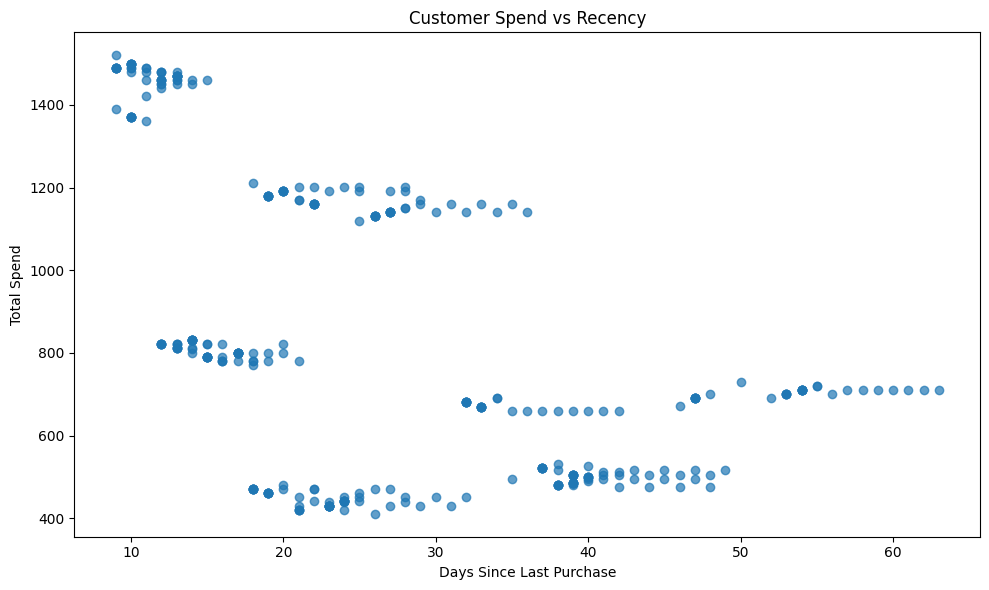

In [71]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_data["Days Since Last Purchase"],
    cluster_data["Total Spend"],
    alpha=0.7
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spend")
plt.title("Customer Spend vs Recency")
plt.tight_layout()
plt.show()

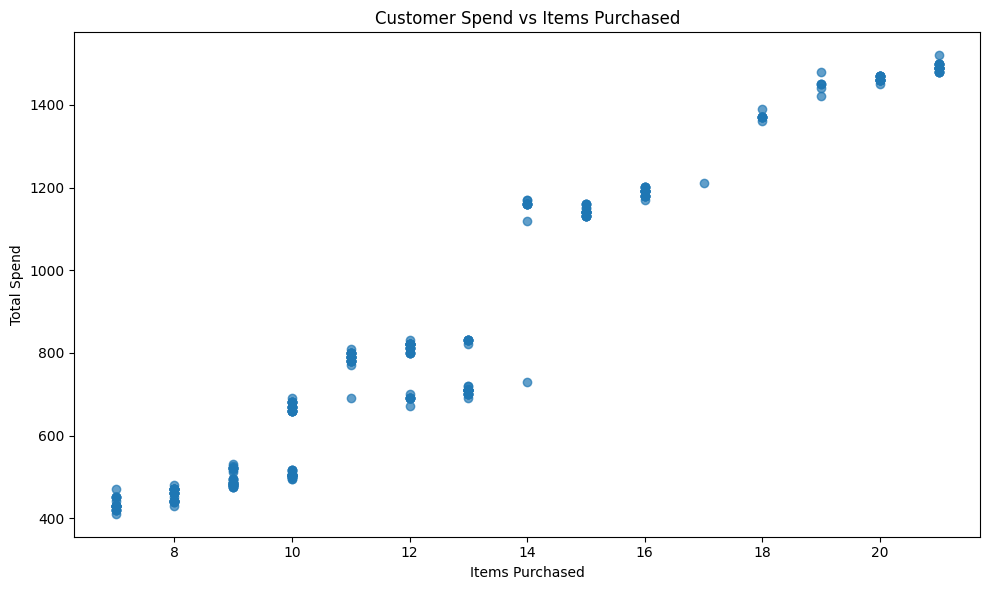

In [72]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_data["Items Purchased"],
    cluster_data["Total Spend"],
    alpha=0.7
)

plt.xlabel("Items Purchased")
plt.ylabel("Total Spend")
plt.title("Customer Spend vs Items Purchased")
plt.tight_layout()
plt.show()

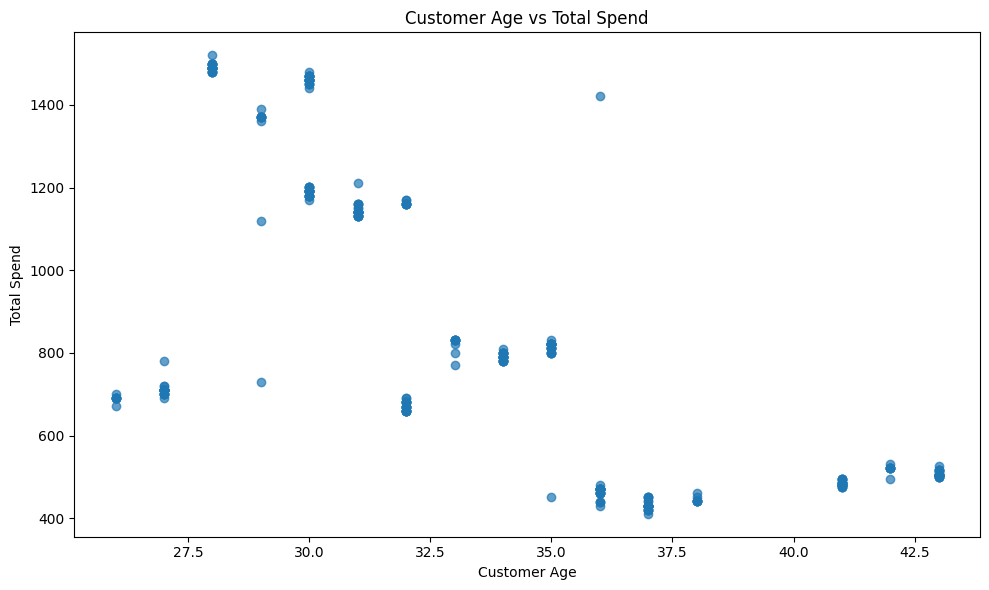

In [73]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_data["Age"],
    cluster_data["Total Spend"],
    alpha=0.7
)

plt.xlabel("Customer Age")
plt.ylabel("Total Spend")
plt.title("Customer Age vs Total Spend")
plt.tight_layout()
plt.show()

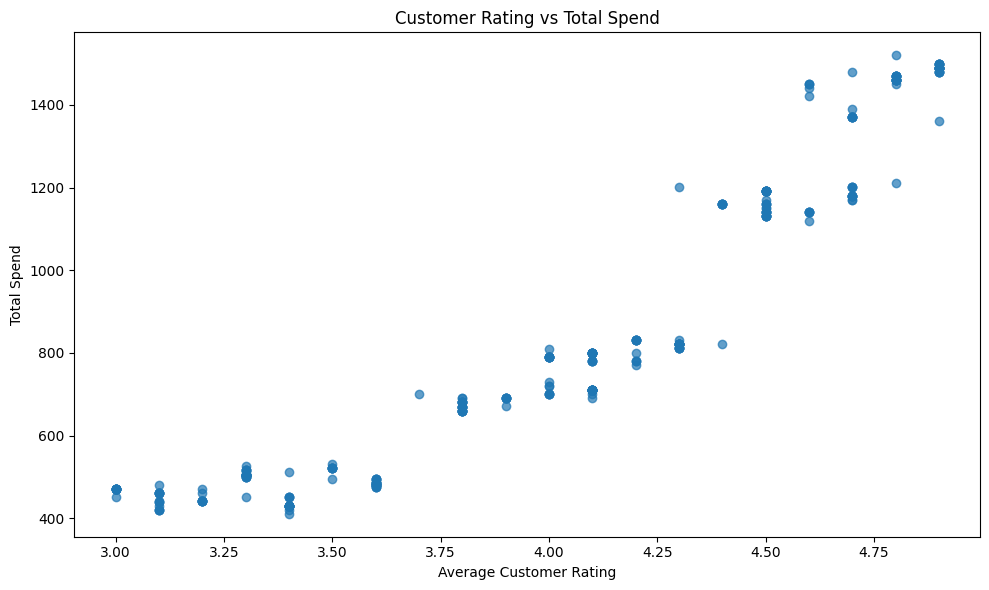

In [74]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_data["Average Rating"],
    cluster_data["Total Spend"],
    alpha=0.7
)

plt.xlabel("Average Customer Rating")
plt.ylabel("Total Spend")
plt.title("Customer Rating vs Total Spend")
plt.tight_layout()
plt.show()

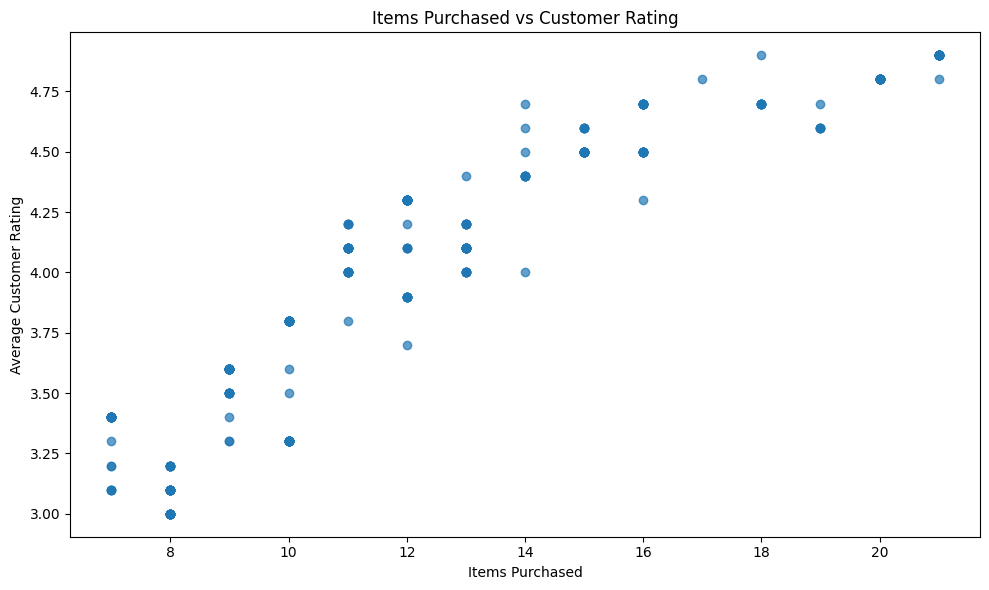

In [75]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_data["Items Purchased"],
    cluster_data["Average Rating"],
    alpha=0.7
)

plt.xlabel("Items Purchased")
plt.ylabel("Average Customer Rating")
plt.title("Items Purchased vs Customer Rating")
plt.tight_layout()
plt.show()

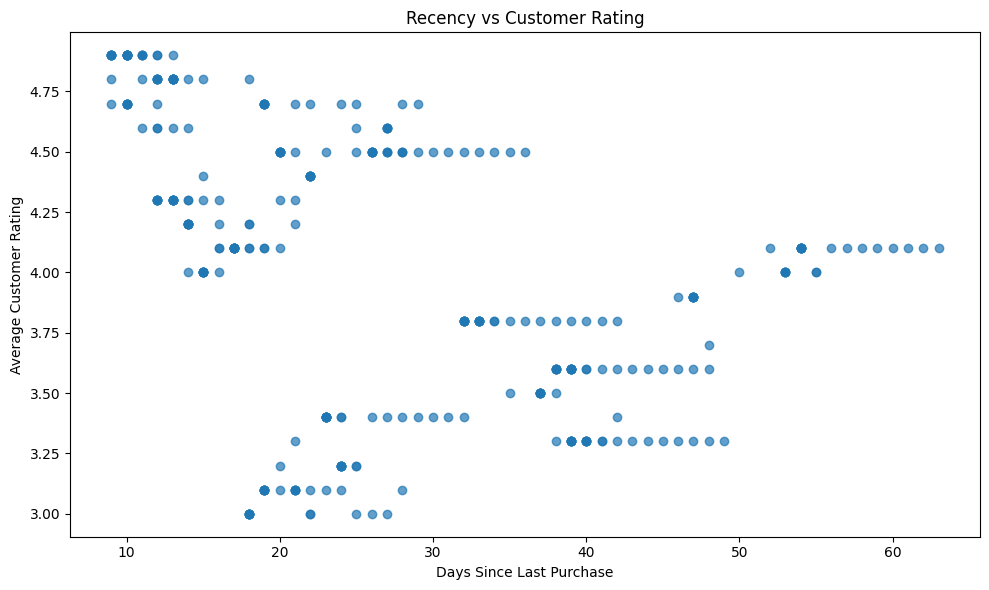

In [76]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_data["Days Since Last Purchase"],
    cluster_data["Average Rating"],
    alpha=0.7
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Average Customer Rating")
plt.title("Recency vs Customer Rating")
plt.tight_layout()
plt.show()

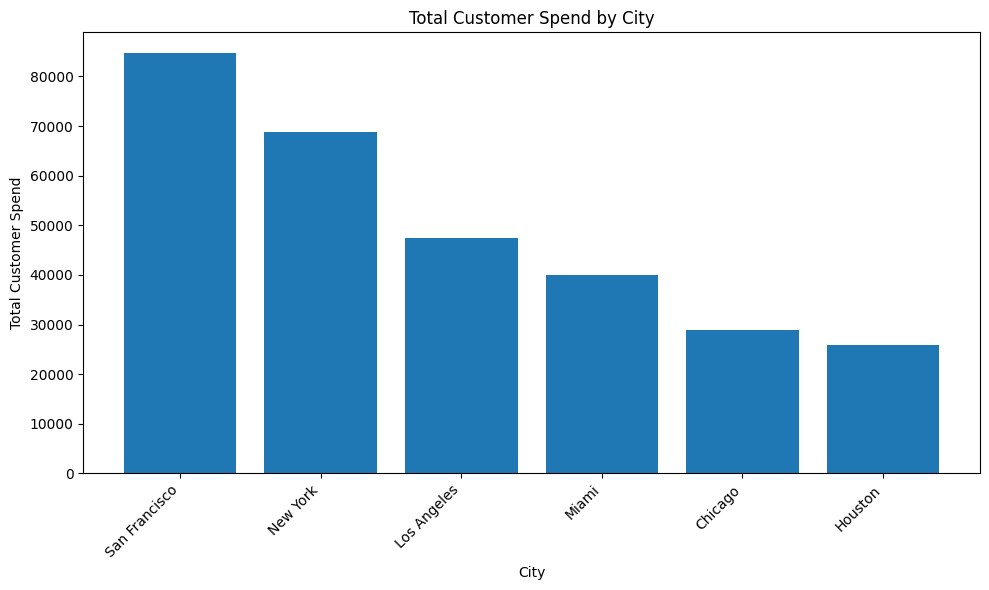

In [77]:
# Calculate total customer spend by city

city_total_spend = (
    cluster_data
    .groupby("City")["Total Spend"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    city_total_spend.index,
    city_total_spend.values
)

plt.xlabel("City")
plt.ylabel("Total Customer Spend")
plt.title("Total Customer Spend by City")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

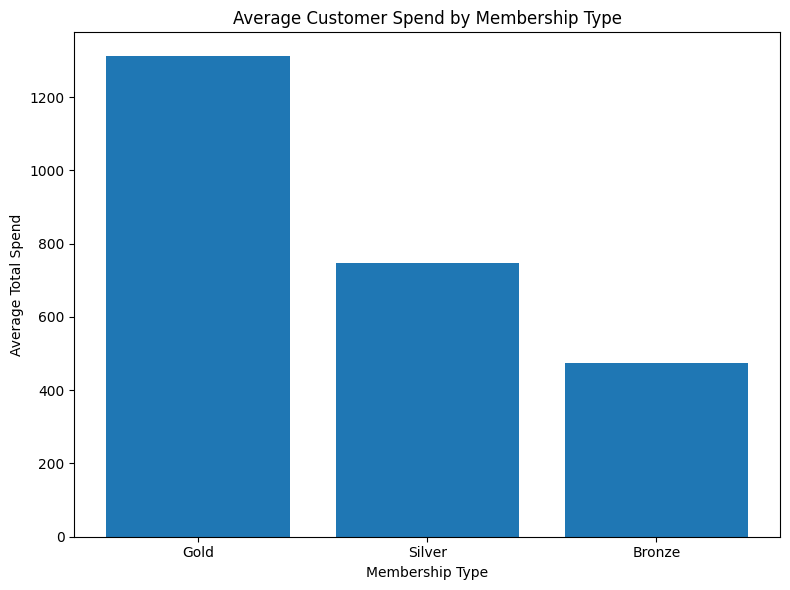

In [78]:
# Calculate average customer spend by membership type

membership_spend = (
    cluster_data
    .groupby("Membership Type")["Total Spend"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

plt.bar(
    membership_spend.index,
    membership_spend.values
)

plt.xlabel("Membership Type")
plt.ylabel("Average Total Spend")
plt.title("Average Customer Spend by Membership Type")
plt.tight_layout()
plt.show()

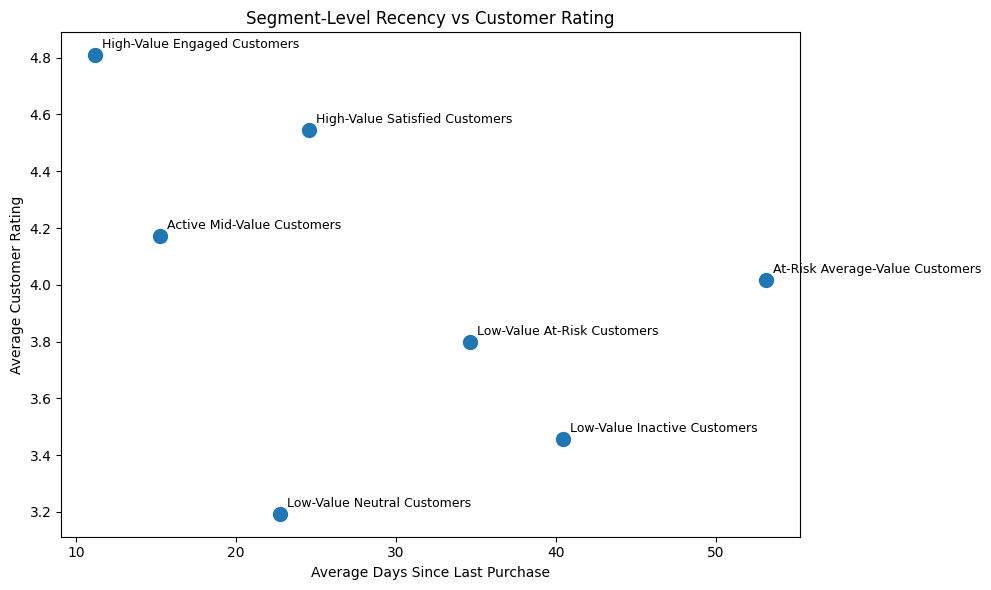

In [79]:
segment_rating_recency = (
    cluster_data
    .groupby("Segment")
    .agg(
        Average_Rating=("Average Rating", "mean"),
        Average_Recency=("Days Since Last Purchase", "mean")
    )
    .reindex(segment_labels.values())
)

plt.figure(figsize=(10, 6))

plt.scatter(
    segment_rating_recency["Average_Recency"],
    segment_rating_recency["Average_Rating"],
    s=100
)

for segment in segment_rating_recency.index:
    x = segment_rating_recency.loc[segment, "Average_Recency"]
    y = segment_rating_recency.loc[segment, "Average_Rating"]
    
    plt.annotate(
        segment,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Average Days Since Last Purchase")
plt.ylabel("Average Customer Rating")
plt.title("Segment-Level Recency vs Customer Rating")
plt.tight_layout()
plt.show()

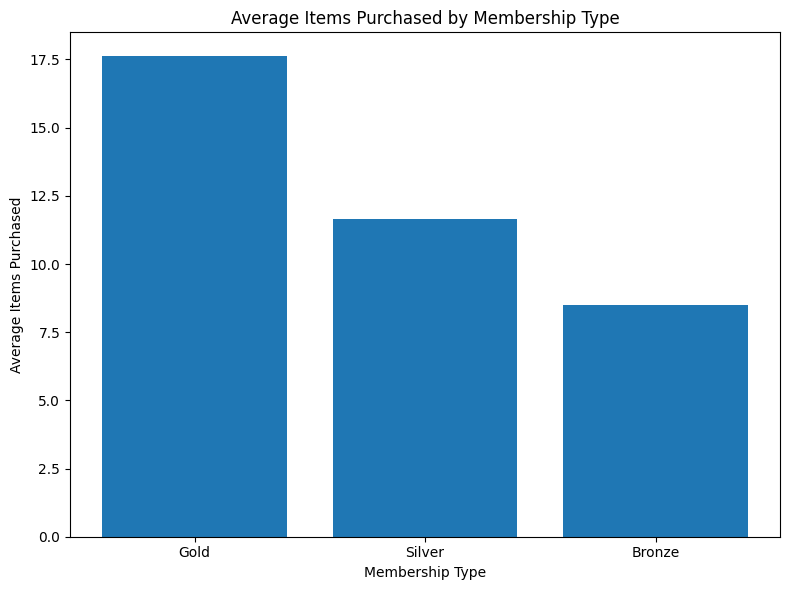

In [80]:
# Calculate average items purchased by membership type

membership_items = (
    cluster_data
    .groupby("Membership Type")["Items Purchased"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

plt.bar(
    membership_items.index,
    membership_items.values
)

plt.xlabel("Membership Type")
plt.ylabel("Average Items Purchased")
plt.title("Average Items Purchased by Membership Type")
plt.tight_layout()
plt.show()

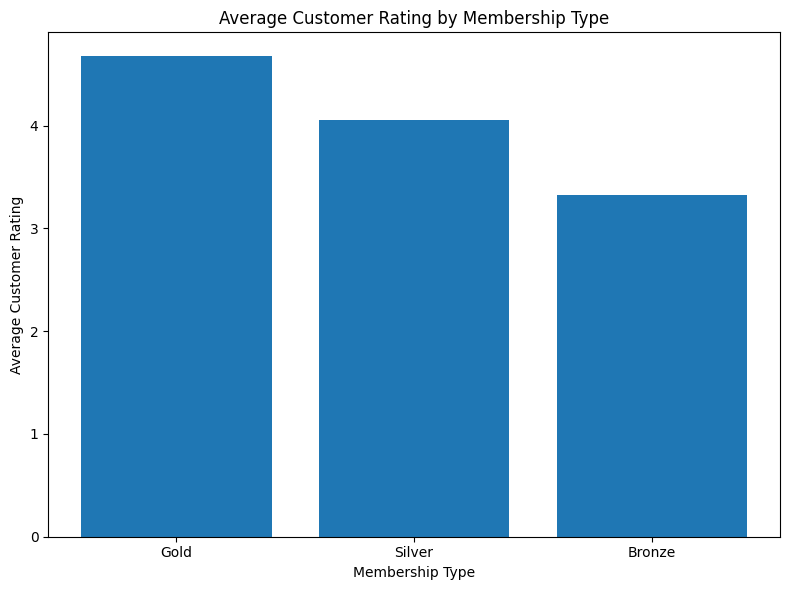

In [81]:
# Calculate average customer rating by membership type

membership_rating = (
    cluster_data
    .groupby("Membership Type")["Average Rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

plt.bar(
    membership_rating.index,
    membership_rating.values
)

plt.xlabel("Membership Type")
plt.ylabel("Average Customer Rating")
plt.title("Average Customer Rating by Membership Type")
plt.tight_layout()
plt.show()

## Limitations

- **City confound (Section 5a).** The five numerical features used for clustering are themselves nearly deterministic functions of `City` in this dataset (non-overlapping ranges, with gaps between cities in several cases). Six of the seven final segments are, in practice, indistinguishable from `groupby("City")`; only one segment split reflects genuine within-city structure. Read the segment profiles as largely City-driven, not as seven independently discovered behavioural personas.
- **Mixed-type clustering caveat (Section 4).** The full-feature and behaviour-focused models combine one-hot-encoded categorical dummies with standardised continuous features under plain Euclidean-distance K-Means, which can let the categorical dummies dominate cluster formation. K-Prototypes or Gower-distance clustering would be a more defensible approach for genuinely mixed-type data.
- **Small, highly structured sample.** n = 350, with unusually clean, non-overlapping numeric bands by City (Section 5a) and silhouette scores (0.71-0.80) far higher than is typical for real-world customer behavioural data. This is consistent with a synthetic or template-generated dataset rather than raw transactional logs. Treat conclusions drawn from this notebook as illustrative of a *methodology*, not as validated findings about a real customer base, unless the data's provenance is independently confirmed.
- **Two missing `Satisfaction Level` values** (2 of 350) were imputed with the column mode. This is a minor, low-impact choice given how few values were missing, but it wasn't stated as a limitation in the original notebook.